# ChordCutter Bot


## Dataset

[Music Bench](https://huggingface.co/datasets/amaai-lab/MusicBench)

## Idea

<strong>Input</strong>: audio file

<strong>Output</strong>: chord sheet

1. Input audio file
2. Audio file gets split into segments (ex: 10s)
3. Each segment gets passed into the NN. Outputs the chord progression and the timestamp
4. Pass the same segment into another NN that generates the lyrics and timestamps
5. Overlay the chords and lyrics based on the timestamps

### Components

1. Audio to chords NN
2. Audio to lyrics NN
3. Chord sheet assembler
4. Data preprocessor (ex: .mp3 to .wav?)


## Data Loading


### Imports

In [2]:
# Libraries
import os
import torch
import requests
import tarfile
import librosa
from io import BytesIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from datasets import load_dataset
import re
import platform

c:\Users\Sean\Documents\GitHub\ChordCutterBot\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
ds = load_dataset("amaai-lab/MusicBench")
ds

DatasetDict({
    train: Dataset({
        features: ['dataset', 'location', 'main_caption', 'alt_caption', 'prompt_aug', 'prompt_ch', 'prompt_bt', 'prompt_bpm', 'prompt_key', 'beats', 'bpm', 'chords', 'chords_time', 'key', 'keyprob', 'is_audioset_eval_mcaps'],
        num_rows: 52768
    })
    test: Dataset({
        features: ['dataset', 'location', 'main_caption', 'alt_caption', 'prompt_aug', 'prompt_ch', 'prompt_bt', 'prompt_bpm', 'prompt_key', 'beats', 'bpm', 'chords', 'chords_time', 'key', 'keyprob', 'is_audioset_eval_mcaps'],
        num_rows: 800
    })
})

In [4]:
train_df_master = ds['train'].to_pandas()
test_df_master = ds['test'].to_pandas()
train_df = train_df_master.copy()
test_df = test_df_master.copy()

train_df.head()
# test_df

# TODO: remove np.nan from chords list

,dataset,location,main_caption,alt_caption,prompt_aug,prompt_ch,prompt_bt,prompt_bpm,prompt_key,beats,bpm,chords,chords_time,key,keyprob,is_audioset_eval_mcaps
0,MusicBench,data_aug2/-0SdAVK79lg_1.wav,This mellow instrumental track showcases a dom...,This song features an electric guitar as the m...,,The chord progression in this song is E.,The beat counts to 4.,The bpm is 112.0.,The key of this song is E major.,"[[0.37212133669135816, 0.9070457581851855, 1.4...",112.0,[E],[0.5400400339790407],"[E, major]",[0.8934084177017212],False
1,MusicBench,data_aug2/-0SdAVK79lg_2.wav,This relaxing song is perfect for a coffee sho...,This song features an electric guitar as the m...,,The chord progression in this song is E.,The beat is 4.,The song is played at the pace of Vivace.,This song is in the key of E major.,"[[0.2658142022146419, 0.6479221178981897, 1.04...",157.0,[E],[0.4485947212378337],"[E, major]",[0.8934084177017212],False
2,MusicBench,data_aug2/-0SdAVK79lg_3.wav,This laid-back instrumental track is perfect f...,This song features an electric guitar as the m...,,The chord progression in this song is E.,The beat counts to 4.,The bpm is 151.0.,The key of this song is E major.,"[[0.2754422138603508, 0.6713903962846051, 1.08...",151.0,[E],[0.3861310098244245],"[E, major]",[0.8934084177017212],False
3,MusicBench,data_aug2/-0SdAVK79lg_4.wav,This is a relaxing song that features an elect...,This song features an electric guitar as the m...,,The chord progression in this song is E.,The beat is 4.,The song is played at the pace of Vivace.,This song is in the key of E major.,"[[0.2801938173601484, 0.6829724298153618, 1.10...",148.0,[E],[0.33809850513698275],"[E, major]",[0.8934084177017212],False
4,MusicBench,data_aug2/-0SdAVK79lg_5.wav,This relaxing song is perfect for a coffee sho...,This song features an electric guitar as the m...,,The chord sequence is C#.,The time signature is 4/4.,This song goes at 130.0 beats per minute.,This song is in the key of C# major.,"[[0.32, 0.78, 1.26, 1.74, 2.2, 2.66, 3.12, 3.5...",130.0,[C#],[0.33809850513698275],"[C#, major]",[0.8934084177017212],False


### Audio Analysis Exploration


In [5]:
def open_audio_file(location='', num=-1):
    ''' 
    Gets the tar file online without reading everything into memory. Iterates through response one file at a time.
    Only considers files (and currently .wav files). Can be used to get a specific file, though this is achieved
    by iterating over every item in the decompressed tar file. Can also be used to get a specific number of files.

    Input
    - location: the filepath (as provided by the "Location" column in the dataset) to retrieve (note: current implementation is very inefficient). Default is the empty string, which will output all files
    - num: the number of files to retrieve, from the beginning. Default is -1, which will output all the files

    Output
    - None
    '''
    url = 'https://huggingface.co/datasets/amaai-lab/MusicBench/resolve/main/MusicBench.tar.gz'
    response = requests.get(url, stream=True)
    print("response received!")
    print(response, '\n')
    retrieved_count = 0
    
    if response.status_code == 200:
        # open tar file as a stream
        with tarfile.open(fileobj=response.raw, mode='r|gz') as tar:
            print("opened tar file!")

            for member in tar:
                # only care about files
                # if location is given, only get that file; otherwise get all files
                if member.isfile() and (member.name == f"datashare/{location}" or not location):
                    file = tar.extractfile(member)
                    print("Type:", type(file))
                    print("File:", file)
                    print(f"File name: {member.name}")

                    file = tar.extractfile(member)
                    print("Extracted file:", file, '\n')

                    # read this file into memory
                    file_bytes = BytesIO(file.read())

                    # only get audio files
                    if member.name.endswith('.wav'):
                        audio_data, sr = librosa.load(file_bytes, sr=None)

                        # metadata
                        print("-----METADATA-----")
                        print(f"Audio length: {len(audio_data)} samples, Sample Rate: {sr}")
                        print(type(audio_data), audio_data.shape)
                        print("audio_data element:", audio_data[0])

                        # sound amplitude
                        plt.plot(audio_data)
                        plt.show()

                        # Mel-frequency cepstral coefficients
                        mfccs = librosa.feature.mfcc(y=audio_data, sr=sr, n_mfcc=13)
                        plt.figure(figsize=(10, 4))
                        librosa.display.specshow(mfccs, sr=sr, x_axis='time')
                        plt.colorbar(label='MFCC')
                        plt.title('MFCCs')
                        plt.show()
                        print("MFCCs:", mfccs.shape)

                        # chroma feature extraction
                        chroma = librosa.feature.chroma_stft(y=audio_data, sr=sr)
                        print("Chroma Shape:", chroma.shape)
                        plt.figure(figsize=(10, 4))
                        librosa.display.specshow(chroma[:, :10], y_axis='chroma', x_axis='time', cmap='coolwarm', sr=sr)
                        plt.colorbar(label='Intensity')
                        plt.title('Chroma Feature Representation')
                        plt.xlabel('Time (seconds)')
                        plt.ylabel('Pitch Class')
                        plt.show()

                        # harmonic-percussive separation
                        harmonic, percussive = librosa.effects.hpss(y=audio_data)

                        plt.figure(figsize=(10, 4))
                        plt.plot(harmonic, label="Harmonic")
                        plt.plot(percussive, label="Percussive")
                        plt.legend()
                        plt.title("Harmonic & Percussive Separation")
                        plt.show()

                        # Constant-Q Transform (CQT)
                        cqt = librosa.cqt(y=audio_data, sr=sr)
                        cqt_db = librosa.amplitude_to_db(abs(cqt))
                        plt.figure(figsize=(10, 4))
                        librosa.display.specshow(cqt_db, sr=sr, x_axis='time', y_axis='cqt_note', cmap='coolwarm')
                        plt.colorbar(label='dB')
                        plt.title('Constant-Q Transform (CQT)')
                        plt.show()

                    file.close()
                    if location:  # stop after finding requested file
                        break
                    else:
                        retrieved_count += 1
                        if retrieved_count == num:
                            break
    else:
        print(f"Failed to download the file: {response.status_code}")

response received!
<Response [200]> 

opened tar file!
Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name=''>
File name: datashare/data_aug2/u3yOMK8SuRI_1.wav
Extracted file: <ExFileObject name=''> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.0


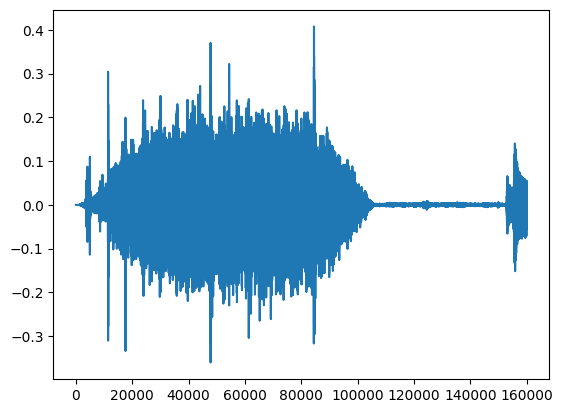

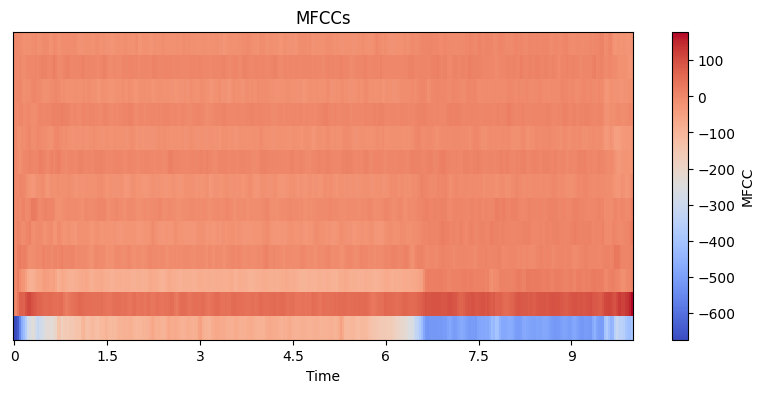

MFCCs: (13, 313)
Chroma Shape: (12, 313)


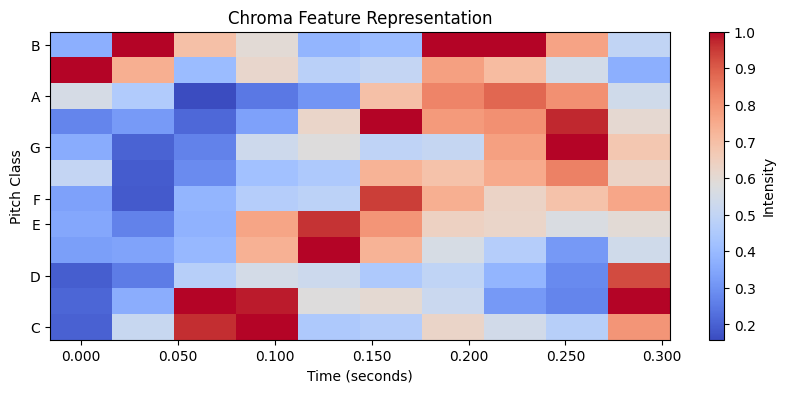

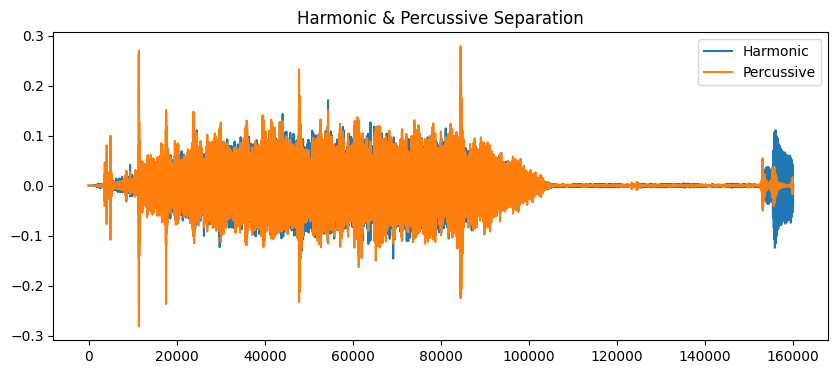

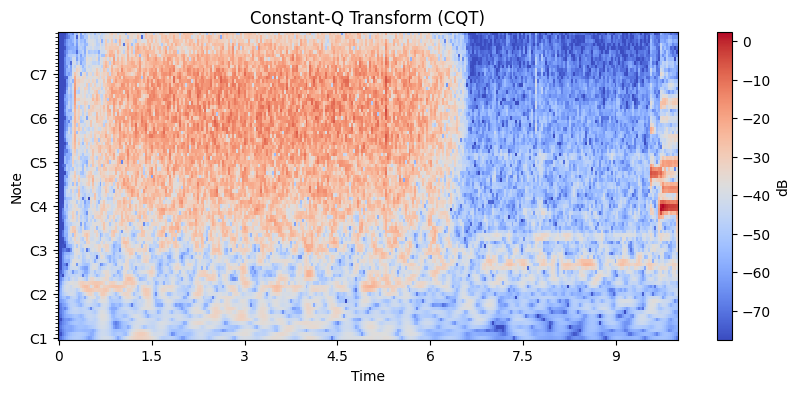

In [6]:
# get specific number of audio files
open_audio_file(num=1)

response received!
<Response [200]> 

opened tar file!
Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name=''>
File name: datashare/data_aug2/u3yOMK8SuRI_1.wav
Extracted file: <ExFileObject name=''> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.0


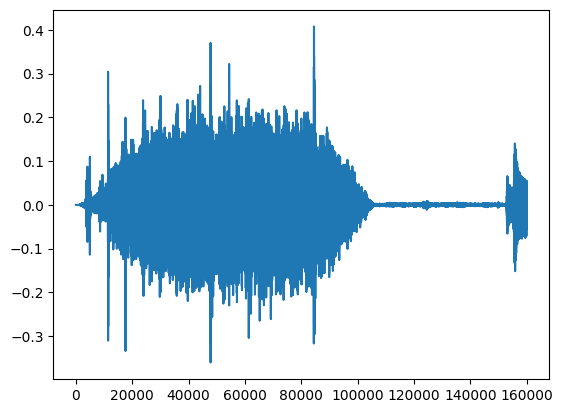

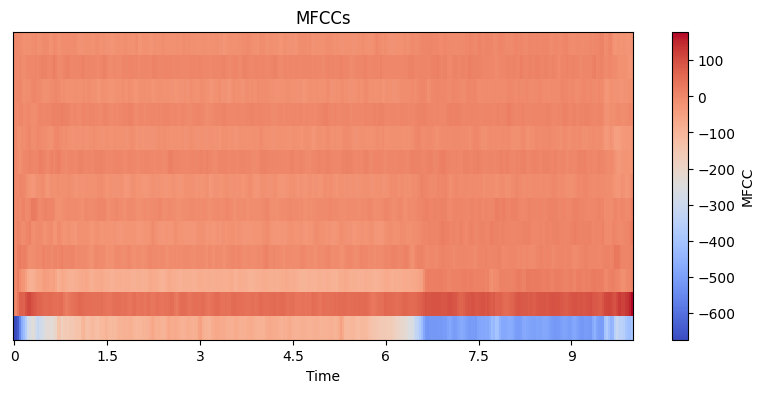

MFCCs: (13, 313)
Chroma Shape: (12, 313)


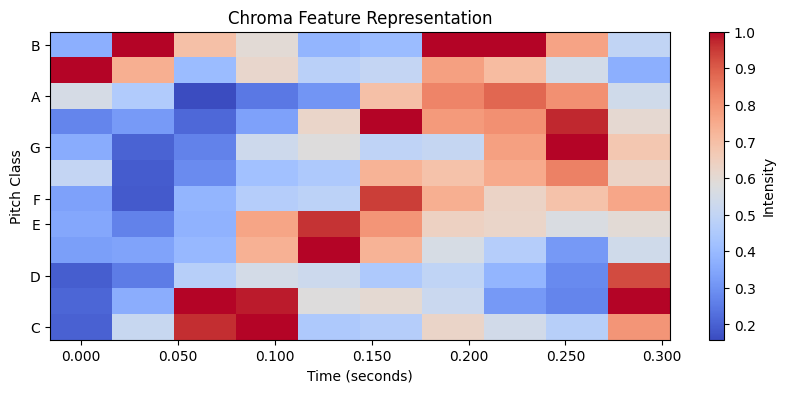

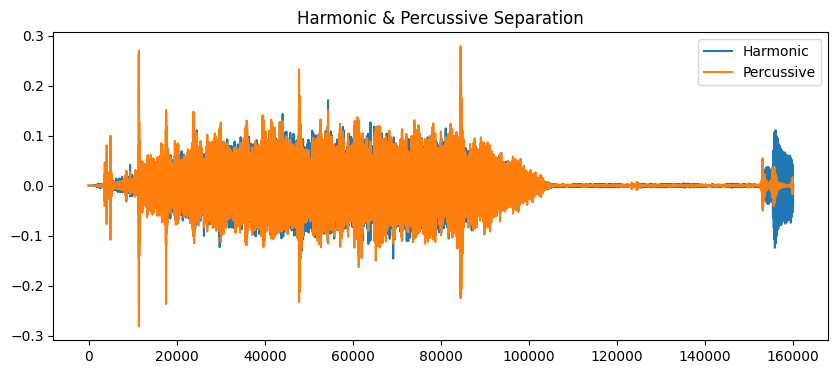

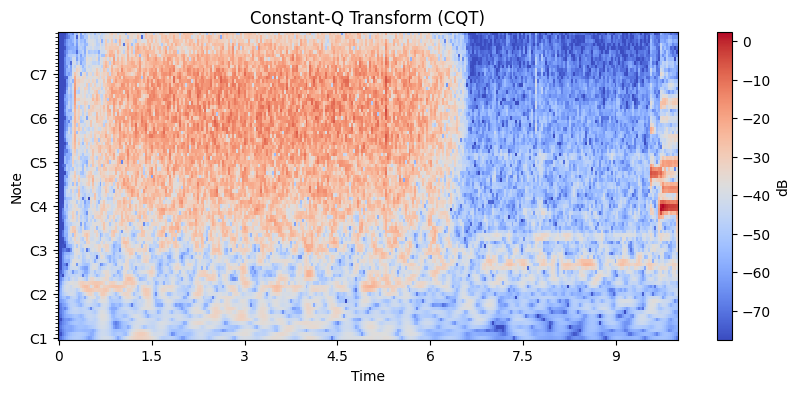

In [7]:
# get audio file by location (see table)
open_audio_file("data_aug2/u3yOMK8SuRI_1.wav")

### Chroma Features Preprocessing


In [8]:
def compute_and_save_chromas(audio_paths, output_dir, sr=None):
    """
    For each filepath in audio_paths:
      - compute chroma
      - save as .npy in output_dir
    """
    os.makedirs(output_dir, exist_ok=True)
    for audio_path in audio_paths:
        # 1) Load the audio
        audio_data, sr_ = librosa.load('datashare/' + audio_path, sr=sr)
        audio_data = librosa.util.normalize(audio_data)

        # 2) Compute chroma (Shape: (12, time_frames))
        chroma_features = librosa.feature.chroma_stft(y=audio_data, sr=sr_)
        chroma_features /= np.max(chroma_features)  # scale [0, 1]

        # 3) Save .npy
        #    e.g. if audio_path = "/path/to/audio/song.wav"
        #    you'll get output_dir + "song.npy"
        filename_stem = os.path.splitext(os.path.basename(audio_path))[0]
        out_path = os.path.join(output_dir, filename_stem + ".npz")
        np.savez(out_path, chroma=chroma_features, sr=sr_)

    print("Precomputation complete!")

In [9]:
# NOTE: you need to run this once to pre-compute the chroma features locally.
# This makes training faster, but there are too many chromas to include in the repo
# compute_and_save_chromas(train_df['location'], "chroma_features")
# compute_and_save_chromas(test_df['location'], "chroma_features_test")

## Library Functions


### Chord Exploration


In [10]:
# Takes in a Series (chords column) and gives a set of unique chords
def get_chord_set(chords: pd.Series) -> set:
    return set(chords.apply(list).explode().unique())

# Returns a list of root chords; simplifies slash chords if necessary
def get_root_chords(chords) -> list:
    return map(lambda x: x.split('/')[0] if is_slash_chord(x) else x, chords)

# Filter for slash chords
def is_slash_chord(chord) -> bool:
    return chord and isinstance(chord, str) and "/" in chord

def extract_unique_base_chords_m_dim(chord_list):
    """
    Extracts unique base chords, preserving "m" and treating "dim" as "m".

    Args:
        chord_list: A list of chord names.

    Returns:
        A list of unique base chords, preserving "m" and treating "dim" as "m".
    """
    unique_chords = []
    for chord in chord_list:
        if chord is None or type(chord) != str:
            continue
        if 'm' in chord and 'dim' not in chord: # add check to avoid double m when dim is converted.
            match = re.match(r'([A-G]#?b?m)', chord)
            if match and match.group(1) not in unique_chords:
                unique_chords.append(match.group(1))
        elif 'dim' in chord:
            match = re.match(r'([A-G]#?b?)dim', chord)
            if match:
                base = match.group(1) + 'm'
                if base not in unique_chords:
                    unique_chords.append(base)
        else:
            match = re.match(r'([A-G]#?b?)', chord)
            if match and match.group(1) not in unique_chords:
                unique_chords.append(match.group(1))

    return unique_chords

def convert_to_simplified(chord_list):
    """
    Same as extract_unique_base_chords_m_dim BUT does not give a unique list.
    Allows for duplicate chords, and retains chord order.
    Preserves "m" and treats "dim" as "m".

    Args:
        chord_list: A list of chord names.

    Returns:
        A list of unique base chords, preserving "m" and treating "dim" as "m".
    """
    simplified_chords = []
    for chord in chord_list:
        if chord is None or type(chord) != str or chord == 'N':
            simplified_chords.append('<PAD>')
        if 'm' in chord and 'dim' not in chord: # add check to avoid double m when dim is converted.
            match = re.match(r'([A-G]#?b?m)', chord)
            if match:
                simplified_chords.append(match.group(1))
        elif 'dim' in chord:
            match = re.match(r'([A-G]#?b?)dim', chord)
            if match:
                base = match.group(1) + 'm'
                simplified_chords.append(base)
        else:
            match = re.match(r'([A-G]#?b?)', chord)
            if match:
                simplified_chords.append(match.group(1))

    if len(simplified_chords) != len(chord_list):
        print("Original:", chord_list)
        print("Simplified:", simplified_chords)

    return simplified_chords

In [11]:
# Chords exploration
chords = train_df['chords']

# Set of all chords
chords_set = set(get_chord_set(chords))

# Set of all slash chords (ex: C/E)
slash_chords = set(filter(is_slash_chord, chords_set))

# Set of root chords of the slash chords (ex: C from C/E)
root_slash = set(get_root_chords(slash_chords))

# Set of (all chords - slash chords) U (root chords)
root_chords = (chords_set - slash_chords).union(root_slash)

print(f"All Chords:\tsize={len(chords_set)}, {chords_set}")
print(f"Slash Chords:\tsize={len(slash_chords)}, {slash_chords}")
print(f"Root Slash:\tsize={len(root_slash)}, {root_slash}")
print(f"Root Chords:\tsize={len(root_chords)}, {root_chords}")
# The number of root chords is the total number of chords minus the number of slash chords
# (there are no roots from slash chords that do not appear in the set of non-slash chords)

All Chords:	size=292, {'Dbdim', 'Gb', 'A#m6', 'E/D', 'G#m6', 'Bm', 'F#/C#', 'Db/D#', 'A7/C#', 'B7', 'G#m7', 'A#7/D', 'Gbm7b5', 'C/G', 'D#m7b5/C#', 'Ab/A#', 'Amaj7', 'Gb6', 'Daug', 'D#dim', 'Abm6', 'Bdim', 'Db', 'Gm7', 'Gm7b5', 'C#7/F', 'D#/C#', 'Cm', 'Bb', 'A', 'F#dim', 'F7/A', 'Aaug', 'Ebm7b5', 'D6', 'G/D', 'Cmaj7', 'F#/A#', 'Ebaug', 'C#7', 'C', 'Dm7b5', 'G#7/C', 'Bbm6', 'F#6', 'D#/G', 'A/E', 'Cdim', 'G/F', 'F/G', 'Dbmaj7', 'Bm7b5/A', 'F#m7', 'C#/F', 'A#aug', 'D#/A#', 'Gm6', 'C#m', 'G#/F#', 'G7/B', 'D/A', 'Fm7', 'A#6', 'Ab6', 'Dbm7', 'A#m', 'Ebm7b5/Db', 'G#6', 'Em', 'G#dim', 'Dbaug', 'Eb7', 'Ebm', 'C6', 'Em7b5/D', 'Cm7', 'Em7', 'F', 'Dbm6', 'Gb7', 'Db/B', 'C#m6', 'Gbm', 'Gmaj7', 'D7/F#', 'G#m7b5/Gb', 'Bbdim', 'Dmaj7', nan, 'Eb', 'Ab/C', 'Gb/Db', 'Db7', 'Gbm6', 'Gbmaj7', 'D#m7b5/Db', 'Bbaug', 'Db/F', 'D#/Db', 'D#m7b5', 'G#', 'A#m7b5/G#', 'Cm6', 'Gm', 'C/D', 'Cm7b5/Bb', 'Ab/D#', 'Ab/Gb', 'E6', 'Gaug', 'Eb6', 'D#6', 'C#maj7', 'A#/D', 'Dm', 'Eb/G', 'Em7b5', 'Db7/F', 'Gdim', 'Bm7b5', 'C#7/

In [12]:
num_chord_classes = len(root_chords)
print(num_chord_classes)

172


In [13]:
new_base_chords = list(map(lambda x: extract_unique_base_chords_m_dim(x), chords))
new_base_chords

flattened_list = []
for sublist in new_base_chords:
    flattened_list.extend(sublist)

len(set(flattened_list))

34

In [14]:
# NOTE: this is just to initialize idx_to_chord and chord_to_idx
# this should should be replicated and called with each model setup
# Preprocessing - Tokenizing for 173 chord classes
root_chords_no_nan = set(filter(lambda item: isinstance(item, str), root_chords))
idx_to_chord = sorted(list(root_chords_no_nan))  # mapping of index-to-chords
idx_to_chord = ['<PAD>'] + idx_to_chord
chord_to_idx = {chord: i for i, chord in enumerate(idx_to_chord)}
print("idx_to_chord:\t", idx_to_chord)
print("chord_to_idx:\t", chord_to_idx)
print('Num Chords:', len(idx_to_chord))

idx_to_chord:	 ['<PAD>', 'A', 'A#', 'A#6', 'A#7', 'A#aug', 'A#dim', 'A#m', 'A#m6', 'A#m7', 'A#m7b5', 'A#maj7', 'A6', 'A7', 'Aaug', 'Ab', 'Ab6', 'Ab7', 'Abaug', 'Abdim', 'Abm', 'Abm6', 'Abm7', 'Abm7b5', 'Abmaj7', 'Adim', 'Am', 'Am6', 'Am7', 'Am7b5', 'Amaj7', 'B', 'B6', 'B7', 'Baug', 'Bb', 'Bb6', 'Bb7', 'Bbaug', 'Bbdim', 'Bbm', 'Bbm6', 'Bbm7', 'Bbm7b5', 'Bbmaj7', 'Bdim', 'Bm', 'Bm6', 'Bm7', 'Bm7b5', 'Bmaj7', 'C', 'C#', 'C#6', 'C#7', 'C#aug', 'C#dim', 'C#m', 'C#m6', 'C#m7', 'C#m7b5', 'C#maj7', 'C6', 'C7', 'Caug', 'Cdim', 'Cm', 'Cm6', 'Cm7', 'Cm7b5', 'Cmaj7', 'D', 'D#', 'D#6', 'D#7', 'D#aug', 'D#dim', 'D#m', 'D#m6', 'D#m7', 'D#m7b5', 'D#maj7', 'D6', 'D7', 'Daug', 'Db', 'Db6', 'Db7', 'Dbaug', 'Dbdim', 'Dbm', 'Dbm6', 'Dbm7', 'Dbm7b5', 'Dbmaj7', 'Ddim', 'Dm', 'Dm6', 'Dm7', 'Dm7b5', 'Dmaj7', 'E', 'E6', 'E7', 'Eaug', 'Eb', 'Eb6', 'Eb7', 'Ebaug', 'Ebdim', 'Ebm', 'Ebm6', 'Ebm7', 'Ebm7b5', 'Ebmaj7', 'Edim', 'Em', 'Em6', 'Em7', 'Em7b5', 'Emaj7', 'F', 'F#', 'F#6', 'F#7', 'F#aug', 'F#dim', 'F#m', 'F#

### Adjust train and test datasets to have base chords


In [15]:
def set_simplified_chords():
    train_df['chords'] = list(map(lambda x: convert_to_simplified(x), train_df_master['chords']))
    test_df['chords'] = list(map(lambda x: convert_to_simplified(x), test_df_master['chords']))

def set_unsimplified_chords():
    train_df['chords'] = train_df_master.copy()['chords']
    test_df['chords'] = test_df_master.copy()['chords']

### Functions


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("mps")

# given list of chord indices and the time of their occurence,
# return a list of chord indices for each time frame
def get_chords_per_frame(chords:list, chord_times:list, num_frames:int, hop_length=512, sr=22050) -> list:
    res = []
    j = 0
    chord = chord_to_idx['<PAD>']
    for i in range(num_frames):
        seconds = frame_to_time(i, hop_length, sr)

        # update the chord if there are more chords and
        # the time frame is in the next chord
        if j < len(chord_times) and seconds >= chord_times[j]:
            chord = chords[j]
            j += 1
        res.append(chord)
    return res

# converts timeframe to time in seconds
def frame_to_time(frame_idx:int, hop_length=512, sr=22050) -> float:
    return (frame_idx * hop_length) / sr

def tokenize_chord_labels(chord_labels: pd.Series) -> list:
    """
    Converts a Pandas Series of chord progressions into a list of token indices via vectorization

    Parameters:
        chord_labels (pd.Series): Series where each entry is a list of chords.

    Returns:
        list: A list of lists containing token indices.
    """
    # Vectorized root chord extraction
    root_chord_labels = chord_labels.apply(lambda chords: list(get_root_chords(chords)))
    
    # Vectorized conversion to indices
    return root_chord_labels.apply(lambda labels: list(map(chord_to_idx.get, labels))).tolist()

def process_chord_progression(chord_idx, sr=22050):
    """
    Takes chord indices (argmax of model output) and returns a collapsed list of chords and their times.
    
    Parameters:
        chord_idx (list or np.ndarray): Sequence of chord indices.
        sr (int): Sample rate, used to convert frame indices to time.

    Returns:
        tuple: (list of unique chords, list of their corresponding start times)
    """
    # Ensure tensor is on CPU before using NumPy functions
    # chord_idx = chord_idx.cpu().numpy()  # Convert from CUDA tensor to NumPy array

    # Find change points where chord transitions occur
    change_points = torch.nonzero(torch.diff(torch.cat([torch.tensor([-1], device=device), chord_idx]), dim=0)).squeeze(1).cpu().tolist()

    # Extract the corresponding chords
    chords = [idx_to_chord[idx] for idx in chord_idx[change_points]]

    # Compute time values for changes
    times = list(map(lambda frame_idx: frame_to_time(frame_idx, sr=sr), change_points))
    # times = frame_to_time(change_points, sr=sr)  # Assuming frame_to_time supports vectorization

    return chords, times

# load checkpoint to model and optimizer
def load_checkpoint(model, opt, checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint['model_state_dict'])
    opt.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    previous_loss = checkpoint['loss']
    return model, opt, start_epoch, previous_loss

# Global variable to store the imported module
_audio_player = None  
def play_audio(file_path: str) -> None:
    """
    Plays a .wav file using the appropriate method based on the operating system.

    Parameters:
        file_path (str): The path to the .wav file.

    Returns:
        None
    """
    global _audio_player

    if _audio_player is None:
        system_name = platform.system()

        if system_name == "Windows":
            import winsound
            _audio_player = winsound
        elif system_name == "Darwin":  # macOS
            from playsound import playsound
            _audio_player = playsound
        else:
            raise RuntimeError(f"Unsupported OS: {system_name}")

    # Play the sound using the cached module
    if platform.system() == "Windows":
        _audio_player.PlaySound(file_path, _audio_player.SND_FILENAME)
    else:  # macOS
        _audio_player(file_path)

ENHARMONICS = {
    # Sharps to flats
    'A#': 'Bb', 'A#m': 'Bbm',
    'B#': 'C', 'B#m': 'Cm',
    'C#': 'Db', 'C#m': 'Dbm',
    'D#': 'Eb', 'D#m': 'Ebm',
    'E#': 'F', 'E#b': 'Fm',
    'F#': 'Gb', 'F#m': 'Gbm',
    'G#': 'Ab', 'G#m': 'Abm',
    # Flats to sharps
    'Ab': 'G#', 'Abm': 'G#m',
    'Bb': 'A#', 'Bbm': 'A#m',
    'Cb': 'B', 'Cbm': 'Bm',
    'Db': 'C#', 'Dbm': 'C#m',
    'Eb': 'D#', 'Ebm': 'D#m',
    'Fb': 'E', 'Fbm': 'Em',
    'Gb': 'F#', 'Gbm': 'F#m'
}

### Evaluation


In [17]:
# TODO: include audio file in output
def sample_eval(model, dataloader:torch.utils.data.DataLoader, batch_idx:int, sub_idx=0, output_dim=256, loss_fn=nn.CrossEntropyLoss(), threshold=0.3, audio=False) -> str:
    model.eval()
    for idx, (sequences, labels, _, srs, filepaths) in enumerate(dataloader):
        if idx == batch_idx:
            sequences, labels = sequences.to(device), labels.to(device)

            with torch.amp.autocast(device_type=str(device), enabled=True):
                out = model(sequences)

                # Flatten logits and labels for PyTorch CrossEntropyLoss
                if isinstance(loss_fn, nn.CrossEntropyLoss):
                    # Flatten outputs and labels
                    logits = out.view(-1, output_dim)
                    targets = labels.reshape(-1)
                else:  # do NOT flatten for custom HarmonicCrossEntropyLoss
                    logits = out
                    targets = labels

                # Calculate loss
                loss = loss_fn(logits, targets).item()

                # Get chord prediction
                out_idx = out.argmax(axis=-1)  # the token indices of highest probability
                out_maxes = torch.softmax(out, dim=-1).max(axis=-1)  # the probabilities

                # Zips together the maximum probability and the chord for each timestamp at song `sub_idx` --> (max_prob, chord)
                print(list(zip(out_maxes.values[sub_idx].detach().cpu(), [idx_to_chord[i] for i in out_idx[sub_idx]]))[100:])

                # Thresholding loop -- convert token probabilities to chords
                out_chords = []
                new_idx = []
                prev_idx = chord_to_idx['<PAD>']
                out_values = out_maxes.values[sub_idx].detach()  # detach so its eaiser to print
                for t, i in enumerate(out_idx[sub_idx]):  # iterate over each timeframe
                    timeframe_max = out_values[t].item()  # the maximum prob for timestamp `t`

                    # update the token index if the probability is above a threshold
                    # AND if the current and previous chords are NOT enharmonic (ex: Eb and D#)
                    if timeframe_max > threshold and ENHARMONICS.get(idx_to_chord[i], None) != idx_to_chord[prev_idx]:
                        prev_idx = i
                    out_chords.append(idx_to_chord[prev_idx])
                    new_idx.append(prev_idx)
                new_out_idx = torch.tensor(new_idx, device=device)

                # convert label (actual) tokens to chords
                label_chords = [[idx_to_chord[chord_idx] for chord_idx in labels[timeframe]] for timeframe in range(len(labels))]

                # Display Summary of Model Performance
                print("Model output shape:", out.shape)
                print("Model idx shape:", out_idx.shape)
                print("Label shape:", labels.shape)
                print("Max classes (chord) per frame:", out_chords)
                print("Labels:", label_chords[sub_idx])
                print()

                # get chord progression for model prediction
                chord_progression, chord_times = process_chord_progression(new_out_idx, srs[sub_idx])
                # get actual chord progression
                label_progression, label_times = process_chord_progression(labels[sub_idx], srs[sub_idx])
                print("Predicted Progression:\t", chord_progression)
                print("Label Progression:\t", label_progression)
                print("Predicted Times:\t", chord_times)
                print("Label Times:\t\t", label_times)
                print("Loss", loss)

                song = filepaths[sub_idx]
                if audio:  # play audio file
                    play_audio(song)
                return song

# Compute loss (bias) over test dataset
def compute_test_loss(model, test_dataloader, loss_fn, output_dim:int):
    model.eval()
    total_loss = 0

    for packed_batch, padded_labels, _, _, _ in test_dataloader:
        packed_batch, padded_labels = packed_batch.to(device), padded_labels.to(device)

        with torch.no_grad():
            outputs = model(packed_batch)
        
            # Flatten outputs and labels
            logits = outputs.view(-1, output_dim)
            labels = padded_labels.reshape(-1)
            loss = loss_fn(logits, labels)
            total_loss += loss.item()
    return total_loss

# Visualize Loss
def plot_loss(train_loss_file:str, test_loss_file:str, num_epochs:int, title:str):
    graph_epochs = np.arange(num_epochs)
    graph_train_loss = []
    graph_test_loss = []

    # read training loss from file
    with open(train_loss_file, 'r') as train_file:
        loss = train_file.readline()
        while loss:
            graph_train_loss.append(float(loss))
            loss = train_file.readline()
    # read test loss from file
    with open(test_loss_file, 'r') as test_file:
        loss = test_file.readline()
        while loss:
            graph_test_loss.append(float(loss))
            loss = test_file.readline()

    plt.plot(graph_epochs, graph_train_loss, label=f"Train - Final loss: {graph_train_loss[-1]:.4}")
    plt.plot(graph_epochs, graph_test_loss, label=f"Test - Final loss: {graph_test_loss[-1]:.4}")
    plt.title("Train vs Test Loss: " + title)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

### Training Loop


In [18]:
def train_model(model, opt, scaler, loss_fn, train_dataloader, test_dataloader, output_dim:int, start_epoch:int, epochs:int, checkpoint_path_root:str, print_interval=10, filename="epoch_loss", lr_scheduler=None):
    for epoch in range(start_epoch, epochs):
        epoch_loss = 0
        for batch_idx, (packed_batch, padded_labels, lengths, _, _) in enumerate(train_dataloader):
            model.train()
            packed_batch, padded_labels, lengths = packed_batch.to(device), padded_labels.to(device), lengths.to(device)

            opt.zero_grad()

            with torch.amp.autocast(device_type=str(device), enabled=True):
                outputs = model(packed_batch)

                # Flatten logits and labels for PyTorch CrossEntropyLoss
                if isinstance(loss_fn, nn.CrossEntropyLoss):
                    # Flatten outputs and labels
                    logits = outputs.view(-1, output_dim)
                    labels = padded_labels.reshape(-1)
                    # print(logits.shape)
                    # print(labels.shape)
                else:  # do NOT flatten for custom HarmonicCrossEntropyLoss
                    logits = outputs
                    labels = padded_labels
                    # print("Input:", packed_batch.data.shape)
                    # print("Logits:", logits.shape)
                    # print("Labels:", padded_labels.shape)

                # Calculate loss
                loss = loss_fn(logits, labels)
                epoch_loss += loss.item()

            # loss.backward()
            # opt.step()
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            if not batch_idx % print_interval: # print every 10 batches, about 250 times per epoch
                print(f'Epoch {epoch + 1}, batch {batch_idx + 1}, Batch Loss: {loss:.7f}')

        # Compute test loss
        average_train_loss = epoch_loss / (batch_idx+1)
        average_test_loss = compute_test_loss(model, test_dataloader, loss_fn, output_dim)
        print(f'---------- Epoch {epoch + 1}, Train Loss: {average_train_loss:.7f}, Test Loss: {average_test_loss:.7f} ----------')

        # Update the learning rate scheduler
        if lr_scheduler:
            lr_scheduler.step(average_test_loss)  # Reduce LR based on validation loss

        # Save train and test epoch loss
        with open(f'{filename}_train.txt', 'a') as train_file:
            train_file.write(str(average_train_loss) + '\n')
        with open(f'{filename}_test.txt', 'a') as test_file:
            test_file.write(str(average_test_loss) + '\n')

        # -- SAVE CHECKPOINT --
        checkpoint_path = f"{checkpoint_path_root}_{epoch+1}.pt"
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': opt.state_dict(),
            'loss': average_train_loss,
            'scaler_state_dict': scaler.state_dict(),
            'lr_scheduler_state_dict': lr_scheduler.state_dict() if lr_scheduler else None
        }, checkpoint_path)

### Dataset and Dataloader


In [19]:
class ChromaDataset(TensorDataset):
    def __init__(self, filepaths, chord_labels, chord_times, npy_dir, device):
        self.filepaths = filepaths
        self.chord_labels = tokenize_chord_labels(chord_labels)
        self.chord_times = chord_times
        self.npy_dir = npy_dir
        self.device = device
    
    def __len__(self):
        return len(self.filepaths)
    
    def __getitem__(self, i):
        """
        Args:
            i: index

        Returns:
            A tuple (chromas, chords, sampling_rate, filepath) of shape ((seq_len, 12), (seq_len,), 1, 1)
        """
        filepath = self.filepaths[i]
        filename_stem = os.path.splitext(os.path.basename(filepath))[0]

        # Load the precomputed chroma
        npz_path = os.path.join(self.npy_dir, filename_stem + ".npz")
        npz_data = np.load(npz_path)  
        chroma_features = npz_data['chroma']  # shape: (12, time_frames)
        sr = int(npz_data['sr'])  # ex: 160000

        # Convert to PyTorch tensor
        chroma_tensor = torch.tensor(chroma_features, dtype=torch.float32)
        
        timeframes = chroma_features.shape[1]
        chord_sequence = get_chords_per_frame(self.chord_labels[i], self.chord_times[i], timeframes, sr=sr)
        chord_sequence = torch.tensor(chord_sequence, dtype=torch.long)

        return chroma_tensor.T, chord_sequence, sr, filepath  # shape: ((seq_len, 12), (seq_len,), 1, 1)

# Used in Dataloader
def collate_fn(batch):
    sequences, labels, srs, filepaths = zip(*batch)  # batch = list of tuples (chroma_features, chord_labels) --> ((seq_length, 12), (seq_length,))

    # OG sequence lengths
    lengths = torch.tensor([seq.shape[0] for seq in sequences], dtype=torch.int64, device=device)

    # sort sequence by descending length for LSTM packing
    sorted_indices = torch.argsort(lengths, descending=True)
    sequences = [sequences[i] for i in sorted_indices]
    labels = [labels[i] for i in sorted_indices]
    lengths = lengths[sorted_indices]
    srs = [srs[i] for i in sorted_indices]
    filepaths = [filepaths[i] for i in sorted_indices]

    # pad sequences to be stacked in batch
    padded_sequences = nn.utils.rnn.pad_sequence(sequences, batch_first=True).to(device)
    packed_sequences = nn.utils.rnn.pack_padded_sequence(padded_sequences, lengths.cpu(), batch_first=True, enforce_sorted=True).to(device)

    # pack sequences for LSTM
    padded_labels = nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value=chord_to_idx['<PAD>']).to(device)

    return packed_sequences, padded_labels, lengths, srs, filepaths

### Harmonic Cross Entropy Loss

In [ ]:
class HarmonicCrossEntropyLoss(nn.Module):
    """
    Combines Cross-Entropy Loss and Fourier-Based Similarity Loss
    for chord classification tasks.
    """
    def __init__(self, chord_embeddings:torch.Tensor, alpha=0.5, ignore_index=None, device='cpu'):
        """
        Args:
            chord_embeddings (torch.Tensor): Precomputed Fourier-based embeddings for each chord index.
                                             Shape: (num_chords, embed_dim)
            alpha (float): Weight for harmonic similarity term (0 <= alpha <= 1).
            ignore_index (int or None): Index to ignore in cross-entropy (e.g. <PAD>).
        """
        super().__init__()
        self.chord_embeddings = chord_embeddings  # shape (num_chords, embed_dim)
        self.alpha = alpha
        self.ignore_index = ignore_index
        self.device = device

        # Standard CrossEntropy. If you have a <PAD> index, you can ignore it:
        if ignore_index is not None:
            self.ce = nn.CrossEntropyLoss(ignore_index=self.ignore_index).to(self.device)
        else:
            self.ce = nn.CrossEntropyLoss().to(self.device)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Args:
            logits (torch.Tensor): Model outputs (logits) of shape (batch_size, seq_len, num_chords)
            targets (torch.Tensor): Ground-truth chord indices of shape (batch_size, seq_len)

        Returns:
            loss (torch.Tensor): Combined loss value.
        """
        with torch.amp.autocast(device_type=str(device), enabled=True):  # accelerate matrix multiplication
            # ------------------------
            # 1) Cross-Entropy Loss
            # ------------------------
            # Flatten for cross entropy: (batch_size*seq_len, num_chords)
            ce_loss = self.ce(
                logits.view(-1, logits.shape[-1]),
                targets.view(-1)
            )

            # ------------------------------------------------
            # 2) Fourier-Based Similarity (Harmonic) Loss
            # ------------------------------------------------
            # Step A: Create a mask
            if self.ignore_index is not None:
                mask = (targets != self.ignore_index)  # (B, T) bool
            else:
                # If no ignore index is given, keep all
                mask = torch.ones_like(targets, dtype=torch.bool, device=self.device)

            # Step B: Convert logits -> probabilities -> predicted chord embeddings
            # Convert logits -> probabilities
            pred_probs = F.softmax(logits, dim=-1).to(self.device)  # (B, T, num_chords)
            # Weighted sum of chord embeddings
            pred_embed = torch.matmul(pred_probs, self.chord_embeddings).to(self.device)  # (B, T, embed_dim)

            # Step C: Gather the ground-truth chord embeddings
            # targets shape: (batch_size, seq_len)
            # chord_embeddings shape: (num_chords, embed_dim)
            true_embed = self.chord_embeddings[targets]  # (B, T, embed_dim)

            # Step D: Compute cosine similarity over embed_dim
            similarity = F.cosine_similarity(pred_embed, true_embed, dim=-1).to(self.device)  # (B, T)

            # Step E: Mask out ignored positions
            masked_similarity = similarity[mask]  # 1-D array of valid positions

            if masked_similarity.numel() == 0:
                # If everything is masked (rare edge case), no harmonic penalty
                harmonic_loss = torch.tensor(0.0, device=self.device, dtype=torch.float32, requires_grad=True)
            else:
                # 1 - similarity => higher when vectors are far apart
                # Mean over all positions
                harmonic_loss = (1.0 - masked_similarity).mean()
                harmonic_loss = harmonic_loss.to(torch.float32).to(device)

        # ------------------------------------------------------
        # 3) Combine cross-entropy and harmonic similarity loss
        # ------------------------------------------------------
        combined_loss = (1 - self.alpha) * ce_loss + self.alpha * harmonic_loss
        return combined_loss

### Tonnetz Embedding

In [21]:
# Optional mapping for root notes to pitch classes
NOTE_TO_PC = {
    'C': 0, 'C#': 1, 'Db': 1, 'D': 2, 'D#': 3, 'Eb': 3, 'E': 4, 'Fb': 4, 'F': 5,
    'F#': 6, 'Gb': 6, 'G': 7, 'G#': 8, 'Ab': 8, 'A': 9, 'A#': 10, 'Bb': 10, 'B': 11, 'Cb': 11
}

# Simple definitions for chord intervals
MAJOR_INTERVALS = [0, 4, 7]
MINOR_INTERVALS = [0, 3, 7]

def chord_label_to_pitch_classes(chord_label: str):
    """
    Parse chord label (e.g. 'C:maj', 'D:min', '<NULL>') into pitch classes.
    Returns a list of integers [0..11].
    """
    # Handle special cases
    if chord_label == "<PAD>":
        return []  # No pitch classes
    
    root = chord_label[0]
    root_pc = NOTE_TO_PC.get(root, 0)

    # Map chord quality to intervals
    if 'm' in chord_label:
        intervals = MINOR_INTERVALS
    else:
        # assume major
        intervals = MAJOR_INTERVALS

    # Compute pitch classes
    pcs = [(root_pc + interval) % 12 for interval in intervals]
    return pcs

def compute_tonnetz_embedding(chord_label: str) -> np.ndarray:
    """
    Returns a 6D Tonnetz embedding for the given chord label using librosa.feature.tonnetz.
    """
    pitch_classes = chord_label_to_pitch_classes(chord_label)
    
    # Build 12D chroma: 1 for pitch classes in the chord, 0 otherwise
    chroma_vec = np.zeros(12, dtype=np.float32)
    for pitch in pitch_classes:
        chroma_vec[pitch] = 1.0

    # Shape must be (12, frames). Here, we have just 1 "frame"
    chroma_2d = chroma_vec[:, np.newaxis]  # shape (12, 1)

    # librosa.feature.tonnetz expects shape (12, n_frames) or a time-series of chroma
    # Returns shape (6, n_frames). We have n_frames=1, so final shape is (6,1)
    tonnetz_2d = librosa.feature.tonnetz(chroma=chroma_2d)

    # Flatten to get a 6D vector
    # tonnetz_2d[:, 0] shape => (6,)
    return tonnetz_2d[:, 0]

compute_tonnetz_embedding("A")

array([ 4.55341815e-01, -4.55341815e-01, -6.66666687e-01,  3.33333343e-01,
        2.88675143e-01,  1.66533454e-16])

### Run Model

In [22]:
def chroma_extraction(file):
    with open(file, "rb") as file_bytes:
        # load and normalize audio file
        audio_data, sr = librosa.load(file, sr=None)
        audio_data = librosa.util.normalize(audio_data)

        # get chroma features (12, T) where T=frames
        chroma_features = librosa.feature.chroma_stft(y=audio_data, sr=sr)
        chroma_features /= np.max(chroma_features)  # scale [0, 1]

        chroma_tensor = torch.tensor(chroma_features, dtype=torch.float32).to(device)
        return chroma_tensor.T, chroma_tensor.shape[1], sr  # Shape=(12, sequence_length, sr)
    
def predict_chords(audiofile:str, model:nn.Module, threshold=0.3, audio=False):
    # Convert to chromas
    chroma_tensors, seq_len, sr = chroma_extraction(audiofile)
    chroma_tensors = chroma_tensors.expand(1, chroma_tensors.shape[0], chroma_tensors.shape[1])
    print(chroma_tensors.shape)

    # Pad and pack for the model
    padded_sequences = nn.utils.rnn.pad_sequence(chroma_tensors, batch_first=True).to(device)
    packed_sequences = nn.utils.rnn.pack_padded_sequence(padded_sequences, [seq_len], batch_first=True, enforce_sorted=True).to(device)

    # Run model
    predictions = model(packed_sequences)
    
    # Get chord predictions
    token_maxes = torch.softmax(predictions, dim=-1).max(axis=-1)  # the probabilities
    token_values = token_maxes.values[0].detach()
    token_indices = token_maxes.indices[0].detach()

    # Thresholding loop -- convert token probabilities to chords
    chords = []
    chord_idx = []
    prev_token = chord_to_idx['<PAD>']
    for timeframe, token in enumerate(token_indices):
        timeframe_max = token_values[timeframe].item()

        # update the token index if the probability is above a threshold
        # AND if the current and previous chords are NOT enharmonic (ex: Eb and D#)
        if timeframe_max > threshold and ENHARMONICS.get(idx_to_chord[token], None) != idx_to_chord[prev_token]:
            prev_token = token
        chords.append(idx_to_chord[prev_token])
        chord_idx.append(prev_token)
    chord_idx_preds = torch.tensor(chord_idx, device=device)

    # Get chord progression for model prediction
    chord_progression, chord_times = process_chord_progression(chord_idx_preds, sr)

    # Display Summary
    print("Model output shape:", predictions.shape)
    print("Model idx shape:", token_indices.shape)
    print("Max chord per frame:", chords)
    print()
    print("Predicted Progression:\t", chord_progression)
    print("Predicted Times:\t", chord_times)

    if audio:
        play_audio(audiofile)
    return audiofile


## Sequence-to-Sequence Models


### LSTM for Chroma Features


#### Model Class Definitions


In [ ]:
class AudioLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(AudioLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(in_features=hidden_dim, out_features=output_dim)

    def forward(self, x):
        packed_output, _ = self.lstm(x)  # run LSTM layer
        output, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        return self.fc(output)  

#### Training


In [ ]:
# Preprocessing - Tokenizing for 173 chord classes
root_chords_no_nan = set(filter(lambda item: isinstance(item, str), root_chords))
idx_to_chord = sorted(list(root_chords_no_nan))  # mapping of index-to-chords
idx_to_chord = ['<PAD>'] + idx_to_chord
chord_to_idx = {chord: i for i, chord in enumerate(idx_to_chord)}
print("idx_to_chord:\t", idx_to_chord)
print("chord_to_idx:\t", chord_to_idx)
print('Num Chords:', len(idx_to_chord))

set_unsimplified_chords()

idx_to_chord:	 ['<PAD>', '<NULL>', 'A', 'A#', 'A#6', 'A#7', 'A#aug', 'A#dim', 'A#m', 'A#m6', 'A#m7', 'A#m7b5', 'A#maj7', 'A6', 'A7', 'Aaug', 'Ab', 'Ab6', 'Ab7', 'Abaug', 'Abdim', 'Abm', 'Abm6', 'Abm7', 'Abm7b5', 'Abmaj7', 'Adim', 'Am', 'Am6', 'Am7', 'Am7b5', 'Amaj7', 'B', 'B6', 'B7', 'Baug', 'Bb', 'Bb6', 'Bb7', 'Bbaug', 'Bbdim', 'Bbm', 'Bbm6', 'Bbm7', 'Bbm7b5', 'Bbmaj7', 'Bdim', 'Bm', 'Bm6', 'Bm7', 'Bm7b5', 'Bmaj7', 'C', 'C#', 'C#6', 'C#7', 'C#aug', 'C#dim', 'C#m', 'C#m6', 'C#m7', 'C#m7b5', 'C#maj7', 'C6', 'C7', 'Caug', 'Cdim', 'Cm', 'Cm6', 'Cm7', 'Cm7b5', 'Cmaj7', 'D', 'D#', 'D#6', 'D#7', 'D#aug', 'D#dim', 'D#m', 'D#m6', 'D#m7', 'D#m7b5', 'D#maj7', 'D6', 'D7', 'Daug', 'Db', 'Db6', 'Db7', 'Dbaug', 'Dbdim', 'Dbm', 'Dbm6', 'Dbm7', 'Dbm7b5', 'Dbmaj7', 'Ddim', 'Dm', 'Dm6', 'Dm7', 'Dm7b5', 'Dmaj7', 'E', 'E6', 'E7', 'Eaug', 'Eb', 'Eb6', 'Eb7', 'Ebaug', 'Ebdim', 'Ebm', 'Ebm6', 'Ebm7', 'Ebm7b5', 'Ebmaj7', 'Edim', 'Em', 'Em6', 'Em7', 'Em7b5', 'Emaj7', 'F', 'F#', 'F#6', 'F#7', 'F#aug', 'F#dim', 

In [ ]:
mock_df = train_df
mock_input_files = "./datashare/" + mock_df["location"]

chroma_ds = ChromaDataset(filepaths=mock_input_files, chord_labels=mock_df['chords'], chord_times=mock_df['chords_time'], npy_dir='chroma_features', device=device)
dataloader = DataLoader(chroma_ds, batch_size=1024, shuffle=True, collate_fn=collate_fn)

packed_sequences, packed_labels, lengths, _ = next(iter(dataloader))
packed_sequences, packed_labels, lengths = packed_sequences.to(device), packed_labels.to(device), lengths.to(device)
print("Packed sequences:", packed_sequences.data.shape)
print("Packed labels:", packed_labels.data.shape)  
print("Sequence lengths:", lengths)

ValueError: too many values to unpack (expected 4)

In [ ]:
input_dim = 12  # Chroma feature dimensions (12, 313) --> 12 pitches
hidden_dim = 128  # hyperparameter
output_dim = 173  # Number of Chords: 172 + <PAD>
num_layers = 2

lstm_model = AudioLSTM(input_dim, hidden_dim, output_dim, num_layers).to(device)
print(lstm_model)

AudioLSTM(
  (lstm): LSTM(12, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=174, bias=True)
)


In [ ]:
# HYPERPARAMETERS
lr = 0.001
regularization = 0.0001
loss_fn = nn.CrossEntropyLoss(ignore_index=chord_to_idx['<PAD>']).to(device)
opt = torch.optim.Adam(lstm_model.parameters(), lr=lr, weight_decay=regularization)
start_epoch = 0
epochs = 19

checkpoint_path = 'checkpoints/simple_rnn_17.pt'
checkpoint = torch.load(checkpoint_path, map_location=device)

# NEW: Load GradScaler
scaler = torch.amp.GradScaler(device, enabled=True)
# the code below is only used for resuming training, so comment out if its your first time running the model
scaler.load_state_dict(checkpoint['scaler_state_dict'])  

lstm_model.load_state_dict(checkpoint['model_state_dict'])
opt.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch'] + 1
previous_loss = checkpoint['loss']
print("Previous Loss:", previous_loss)

In [ ]:
train_model(lstm_model, opt, scaler, loss_fn, dataloader, output_dim, start_epoch, epochs, "checkpoints/simple_rnn")

#### Testing


In [ ]:
sample_eval(lstm_model, dataloader, 2)

tensor(68)
Model output shape: torch.Size([1024, 313, 174])
Modle idx shape: torch.Size([1024, 313])
Label shape: torch.Size([314609])
Max classes (chord) per frame: ['Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbaug', 'Gbau

### Bidirectional LSTM


Bidirectional LSTM instead of normal LSTM, 4 layers instead of 2, 256 hidden dims instead of 128, layer normalization, dropout = 0.2


#### Model Class Definitions


In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("mps")

class AudioBiLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout):
        super(AudioBiLSTM, self).__init__()
        # Bidirectional LSTM
        self.lstm = nn.LSTM(input_size=input_dim,
                            hidden_size=hidden_dim,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout,
                            bidirectional=True)
        # Layer Normalization
        self.layernorm = nn.LayerNorm(hidden_dim * 2)
        # Fully Connected Layer
        self.fc = nn.Linear(in_features=hidden_dim * 2, out_features=output_dim)

    def forward(self, x):
        packed_output, _ = self.lstm(x)  # run LSTM layer
        output, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        output_normalized = self.layernorm(output)
        return self.fc(output_normalized)

#### Training


In [40]:
# Preprocessing - Tokenizing for 35 chord classes
root_chords_no_nan = set(filter(lambda item: isinstance(item, str), root_chords))
idx_to_chord = sorted(list(root_chords_no_nan))  # mapping of index-to-chords
base_chords = extract_unique_base_chords_m_dim(idx_to_chord)
idx_to_chord = sorted(list(base_chords))  # mapping of index-to-chords
idx_to_chord = ['<PAD>', '<NULL>'] + idx_to_chord
chord_to_idx = {chord: i for i, chord in enumerate(idx_to_chord)}
print("idx_to_chord:\t", idx_to_chord)
print("chord_to_idx:\t", chord_to_idx)
print('Num Chords:', len(idx_to_chord))
print('Num Base Chords:', len(set(base_chords)))

set_simplified_chords()

idx_to_chord:	 ['<PAD>', '<NULL>', 'A', 'A#', 'A#m', 'Ab', 'Abm', 'Am', 'B', 'Bb', 'Bbm', 'Bm', 'C', 'C#', 'C#m', 'Cm', 'D', 'D#', 'D#m', 'Db', 'Dbm', 'Dm', 'E', 'Eb', 'Ebm', 'Em', 'F', 'F#', 'F#m', 'Fm', 'G', 'G#', 'G#m', 'Gb', 'Gbm', 'Gm']
chord_to_idx:	 {'<PAD>': 0, '<NULL>': 1, 'A': 2, 'A#': 3, 'A#m': 4, 'Ab': 5, 'Abm': 6, 'Am': 7, 'B': 8, 'Bb': 9, 'Bbm': 10, 'Bm': 11, 'C': 12, 'C#': 13, 'C#m': 14, 'Cm': 15, 'D': 16, 'D#': 17, 'D#m': 18, 'Db': 19, 'Dbm': 20, 'Dm': 21, 'E': 22, 'Eb': 23, 'Ebm': 24, 'Em': 25, 'F': 26, 'F#': 27, 'F#m': 28, 'Fm': 29, 'G': 30, 'G#': 31, 'G#m': 32, 'Gb': 33, 'Gbm': 34, 'Gm': 35}
Num Chords: 36
Num Base Chords: 34


In [41]:
input_files = "./datashare/" + train_df["location"]
test_input_files = "./datashare/" + test_df['location']

train_chroma_ds = ChromaDataset(filepaths=input_files, chord_labels=train_df['chords'], chord_times=train_df['chords_time'], npy_dir='chroma_features', device=device)
test_chroma_ds = ChromaDataset(filepaths=test_input_files, chord_labels=test_df['chords'], chord_times=test_df['chords_time'], npy_dir='chroma_features_test', device=device)
train_dataloader = DataLoader(train_chroma_ds, batch_size=512, shuffle=True, collate_fn=collate_fn)
test_dataloader = DataLoader(test_chroma_ds, batch_size=512, shuffle=False, collate_fn=collate_fn)

# Examine dataloader
packed_sequences, packed_labels, lengths, _, _ = next(iter(train_dataloader))
packed_sequences, packed_labels, lengths = packed_sequences.to(device), packed_labels.to(device), lengths.to(device)
print("Packed sequences:", packed_sequences.data.shape)
print("Packed labels:", packed_labels.data.shape)  
print("Sequence lengths:", lengths[:10])

Packed sequences: torch.Size([157053, 12])
Packed labels: torch.Size([512, 313])
Sequence lengths: tensor([313, 313, 313, 313, 313, 313, 313, 313, 313, 313], device='cuda:0')


In [42]:
input_dim = 12  # Chroma feature dimensions (12, 313) --> 12 pitches
hidden_dim = 256  # hyperparameter
output_dim = 36  # Number of Chords: 34 + <PAD> + <NULL>
num_layers = 3
dropout = 0.2

bilstm_model = AudioBiLSTM(input_dim, hidden_dim, output_dim, num_layers, dropout).to(device)
print(bilstm_model)

AudioBiLSTM(
  (lstm): LSTM(12, 256, num_layers=3, batch_first=True, dropout=0.2, bidirectional=True)
  (layernorm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=512, out_features=36, bias=True)
)


In [43]:
# HYPERPARAMETERS
lr = 0.003
regularization = 0.003
loss_fn = nn.CrossEntropyLoss(ignore_index=chord_to_idx['<PAD>']).to(device)
start_epoch = 0
epochs = 100

# CHECKPOINTING
checkpoint_path = 'checkpoints/bidirectional_lstm2_100.pt'
checkpoint = torch.load(checkpoint_path, map_location=device)

# Load checkpoint model state
bilstm_model.load_state_dict(checkpoint['model_state_dict'])

# Load checkpoint optimizer state
opt = torch.optim.Adam(bilstm_model.parameters(), lr=lr, weight_decay=regularization)
opt.load_state_dict(checkpoint['optimizer_state_dict'])

# Load Learning Rate Scheduler
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5, verbose=True)
lr_scheduler.load_state_dict(checkpoint['lr_scheduler_state_dict'])

# Load GradScaler
scaler = torch.amp.GradScaler(device, enabled=True)
scaler.load_state_dict(checkpoint['scaler_state_dict'])  

# Other checkpoint vals
start_epoch = checkpoint['epoch'] + 1
previous_loss = checkpoint['loss']
print("Previous Loss:", previous_loss)

Previous Loss: 1.9163679308616197


c:\Users\Sean\Documents\GitHub\ChordCutterBot\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [ ]:
train_model(bilstm_model, opt, scaler, loss_fn,
            train_dataloader, test_dataloader,
            output_dim, start_epoch, epochs,
            "checkpoints/bidirectional_lstm2", 10, "bilstm2_epoch_loss",
            lr_scheduler=lr_scheduler)

Epoch 1, batch 1, Batch Loss: 3.7870727
Epoch 1, batch 11, Batch Loss: 3.3166559
Epoch 1, batch 21, Batch Loss: 3.2661610
Epoch 1, batch 31, Batch Loss: 3.2644582
Epoch 1, batch 41, Batch Loss: 3.2426810
Epoch 1, batch 51, Batch Loss: 3.1609669
Epoch 1, batch 61, Batch Loss: 3.0474768
Epoch 1, batch 71, Batch Loss: 2.9420981
Epoch 1, batch 81, Batch Loss: 2.9201291
Epoch 1, batch 91, Batch Loss: 2.7318835
Epoch 1, batch 101, Batch Loss: 2.6593585
---------- Epoch 1, Train Loss: 3.1803718, Test Loss: 5.2077410 ----------
Epoch 2, batch 1, Batch Loss: 2.6989934
Epoch 2, batch 11, Batch Loss: 2.7528961
Epoch 2, batch 21, Batch Loss: 2.6098115
Epoch 2, batch 31, Batch Loss: 2.5274372
Epoch 2, batch 41, Batch Loss: 2.4046116
Epoch 2, batch 51, Batch Loss: 2.3541036
Epoch 2, batch 61, Batch Loss: 2.4651306
Epoch 2, batch 71, Batch Loss: 2.3781474
Epoch 2, batch 81, Batch Loss: 2.3459466
Epoch 2, batch 91, Batch Loss: 2.3493190
Epoch 2, batch 101, Batch Loss: 2.3633230
---------- Epoch 2, Tra

#### Testing


In [44]:
# Threshold = 0
audiofile = sample_eval(bilstm_model, test_dataloader, 0, 401, output_dim, loss_fn, 0, audio=False)

[(tensor(0.3814), 'Ebm'), (tensor(0.3834), 'Ebm'), (tensor(0.3855), 'Ebm'), (tensor(0.3875), 'Ebm'), (tensor(0.3899), 'Ebm'), (tensor(0.3925), 'Ebm'), (tensor(0.3941), 'Ebm'), (tensor(0.3962), 'Ebm'), (tensor(0.3974), 'Ebm'), (tensor(0.3992), 'Ebm'), (tensor(0.4011), 'Ebm'), (tensor(0.4020), 'Ebm'), (tensor(0.4035), 'Ebm'), (tensor(0.4035), 'Ebm'), (tensor(0.4043), 'Ebm'), (tensor(0.4043), 'Ebm'), (tensor(0.4046), 'Ebm'), (tensor(0.4046), 'Ebm'), (tensor(0.4035), 'Ebm'), (tensor(0.4026), 'Ebm'), (tensor(0.4010), 'Ebm'), (tensor(0.3994), 'Ebm'), (tensor(0.3976), 'Ebm'), (tensor(0.3967), 'Ebm'), (tensor(0.3945), 'Ebm'), (tensor(0.3923), 'Ebm'), (tensor(0.3907), 'Ebm'), (tensor(0.3886), 'Ebm'), (tensor(0.3875), 'Ebm'), (tensor(0.3858), 'Ebm'), (tensor(0.3847), 'Ebm'), (tensor(0.3832), 'Ebm'), (tensor(0.3811), 'Ebm'), (tensor(0.3786), 'Ebm'), (tensor(0.3755), 'Ebm'), (tensor(0.3724), 'Ebm'), (tensor(0.3685), 'Ebm'), (tensor(0.3645), 'Ebm'), (tensor(0.3597), 'Ebm'), (tensor(0.3535), 'Ebm'),

In [33]:
# Threshold = 0.2
audiofile = sample_eval(bilstm_model, test_dataloader, 0, 401, output_dim, loss_fn, 0.2, audio=False)

[(tensor(0.3814), 'Ebm'), (tensor(0.3834), 'Ebm'), (tensor(0.3855), 'Ebm'), (tensor(0.3875), 'Ebm'), (tensor(0.3899), 'Ebm'), (tensor(0.3925), 'Ebm'), (tensor(0.3941), 'Ebm'), (tensor(0.3962), 'Ebm'), (tensor(0.3974), 'Ebm'), (tensor(0.3992), 'Ebm'), (tensor(0.4011), 'Ebm'), (tensor(0.4020), 'Ebm'), (tensor(0.4035), 'Ebm'), (tensor(0.4035), 'Ebm'), (tensor(0.4043), 'Ebm'), (tensor(0.4043), 'Ebm'), (tensor(0.4046), 'Ebm'), (tensor(0.4046), 'Ebm'), (tensor(0.4035), 'Ebm'), (tensor(0.4026), 'Ebm'), (tensor(0.4010), 'Ebm'), (tensor(0.3994), 'Ebm'), (tensor(0.3976), 'Ebm'), (tensor(0.3967), 'Ebm'), (tensor(0.3945), 'Ebm'), (tensor(0.3923), 'Ebm'), (tensor(0.3907), 'Ebm'), (tensor(0.3886), 'Ebm'), (tensor(0.3875), 'Ebm'), (tensor(0.3858), 'Ebm'), (tensor(0.3847), 'Ebm'), (tensor(0.3832), 'Ebm'), (tensor(0.3811), 'Ebm'), (tensor(0.3786), 'Ebm'), (tensor(0.3755), 'Ebm'), (tensor(0.3724), 'Ebm'), (tensor(0.3685), 'Ebm'), (tensor(0.3645), 'Ebm'), (tensor(0.3597), 'Ebm'), (tensor(0.3535), 'Ebm'),

In [35]:
predict_chords(audiofile, bilstm_model, 0.2, True)

torch.Size([1, 313, 12])
Model output shape: torch.Size([1, 313, 36])
Model idx shape: torch.Size([313])
Max chord per frame: ['<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', 'D#m', '

'./datashare/data/-Dtir74TiUM.wav'

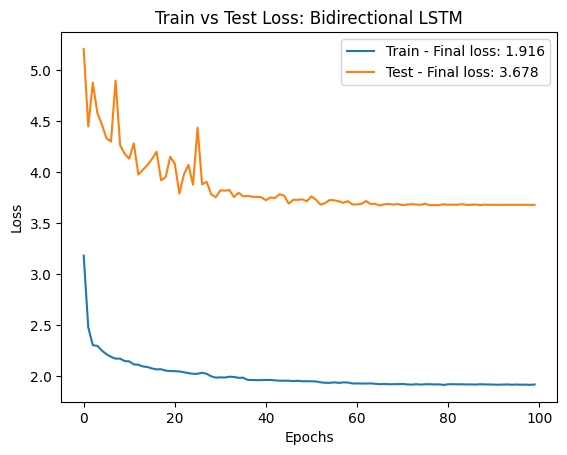

In [30]:
plot_loss("bilstm2_epoch_loss_train.txt", "bilstm2_epoch_loss_test.txt", epochs, "Bidirectional LSTM")

### Larger LSTM - Unsimplified Chords


LSTM model with 4 layers instead of 2, 256 hidden dims instead of 128, and 0.001 regularization instead of 0.0001.

The Bidirectional LSTM model was too computationally expensive, taking about 4-5 hours to complete 1 epoch. This model is more complex xthan the simple LSTM, but not bidirectional


#### Model Class Definitions


In [ ]:
class AudioLargeLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout):
        super(AudioLargeLSTM, self).__init__()
        # LSTM with dropout
        self.lstm = nn.LSTM(input_size=input_dim,
                            hidden_size=hidden_dim,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout)
        # Layer Normalization
        self.layernorm = nn.LayerNorm(hidden_dim)
        # Fully Connected Layer
        self.fc = nn.Linear(in_features=hidden_dim, out_features=output_dim)

    def forward(self, x):
        packed_output, _ = self.lstm(x)  # run LSTM layer
        output, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        output_normalized = self.layernorm(output)
        return self.fc(output_normalized)

#### Training


In [ ]:
# Preprocessing - Tokenizing for 173 chord classes
root_chords_no_nan = set(filter(lambda item: isinstance(item, str), root_chords))
idx_to_chord = sorted(list(root_chords_no_nan))  # mapping of index-to-chords
idx_to_chord = ['<PAD>'] + idx_to_chord
chord_to_idx = {chord: i for i, chord in enumerate(idx_to_chord)}
print("idx_to_chord:\t", idx_to_chord)
print("chord_to_idx:\t", chord_to_idx)
print('Num Chords:', len(idx_to_chord))

set_unsimplified_chords()

idx_to_chord:	 ['<PAD>', '<NULL>', 'A', 'A#', 'A#6', 'A#7', 'A#aug', 'A#dim', 'A#m', 'A#m6', 'A#m7', 'A#m7b5', 'A#maj7', 'A6', 'A7', 'Aaug', 'Ab', 'Ab6', 'Ab7', 'Abaug', 'Abdim', 'Abm', 'Abm6', 'Abm7', 'Abm7b5', 'Abmaj7', 'Adim', 'Am', 'Am6', 'Am7', 'Am7b5', 'Amaj7', 'B', 'B6', 'B7', 'Baug', 'Bb', 'Bb6', 'Bb7', 'Bbaug', 'Bbdim', 'Bbm', 'Bbm6', 'Bbm7', 'Bbm7b5', 'Bbmaj7', 'Bdim', 'Bm', 'Bm6', 'Bm7', 'Bm7b5', 'Bmaj7', 'C', 'C#', 'C#6', 'C#7', 'C#aug', 'C#dim', 'C#m', 'C#m6', 'C#m7', 'C#m7b5', 'C#maj7', 'C6', 'C7', 'Caug', 'Cdim', 'Cm', 'Cm6', 'Cm7', 'Cm7b5', 'Cmaj7', 'D', 'D#', 'D#6', 'D#7', 'D#aug', 'D#dim', 'D#m', 'D#m6', 'D#m7', 'D#m7b5', 'D#maj7', 'D6', 'D7', 'Daug', 'Db', 'Db6', 'Db7', 'Dbaug', 'Dbdim', 'Dbm', 'Dbm6', 'Dbm7', 'Dbm7b5', 'Dbmaj7', 'Ddim', 'Dm', 'Dm6', 'Dm7', 'Dm7b5', 'Dmaj7', 'E', 'E6', 'E7', 'Eaug', 'Eb', 'Eb6', 'Eb7', 'Ebaug', 'Ebdim', 'Ebm', 'Ebm6', 'Ebm7', 'Ebm7b5', 'Ebmaj7', 'Edim', 'Em', 'Em6', 'Em7', 'Em7b5', 'Emaj7', 'F', 'F#', 'F#6', 'F#7', 'F#aug', 'F#dim', 

In [ ]:
input_files = "./datashare/" + train_df["location"]
test_input_files = "./datashare/" + test_df['location']

train_chroma_ds = ChromaDataset(filepaths=input_files, chord_labels=train_df['chords'], chord_times=train_df['chords_time'], npy_dir='chroma_features', device=device)
test_chroma_ds = ChromaDataset(filepaths=test_input_files, chord_labels=test_df['chords'], chord_times=test_df['chords_time'], npy_dir='chroma_features_test', device=device)
train_dataloader = DataLoader(train_chroma_ds, batch_size=2048, shuffle=True, collate_fn=collate_fn)
test_dataloader = DataLoader(test_chroma_ds, batch_size=2048, shuffle=False, collate_fn=collate_fn)

# Examine dataloader
packed_sequences, packed_labels, lengths, _, _ = next(iter(train_dataloader))
packed_sequences, packed_labels, lengths = packed_sequences.to(device), packed_labels.to(device), lengths.to(device)
print("Packed sequences:", packed_sequences.data.shape)
print("Packed labels:", packed_labels.data.shape)
print("Sequence lengths:", lengths[:10])

Packed sequences: torch.Size([629074, 12])
Packed labels: torch.Size([2048, 313])
Sequence lengths: tensor([313, 313, 313, 313, 313, 313, 313, 313, 313, 313])


In [ ]:
input_dim = 12  # Chroma feature dimensions (12, 313) --> 12 pitches
hidden_dim = 256  # hyperparameter
output_dim = 173  # Number of Chords: 172 + <PAD> 
num_layers = 4
dropout = 0.2

large_lstm_model = AudioLargeLSTM(input_dim, hidden_dim, output_dim, num_layers, dropout).to(device)
print(large_lstm_model)

AudioLargeLSTM(
  (lstm): LSTM(12, 256, num_layers=4, batch_first=True, dropout=0.2)
  (layernorm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=256, out_features=173, bias=True)
)


In [ ]:
# HYPERPARAMETERS
lr = 0.001
regularization = 0.001
loss_fn = nn.CrossEntropyLoss(ignore_index=chord_to_idx['<PAD>']).to(device)
start_epoch = 0
epochs = 200

# CHECKPOINTING
checkpoint_path = 'checkpoints/large_lstm_200.pt'
checkpoint = torch.load(checkpoint_path, map_location=device)

# Load checkpoint model state
large_lstm_model.load_state_dict(checkpoint['model_state_dict'])

# Load checkpoint optimizer state
opt = torch.optim.Adam(large_lstm_model.parameters(), lr=lr, weight_decay=regularization)
opt.load_state_dict(checkpoint['optimizer_state_dict'])

# NEW: Load GradScaler
scaler = torch.amp.GradScaler(device, enabled=True)
# the code below is only used for resuming training, so comment out if its your first time running the model
scaler.load_state_dict(checkpoint['scaler_state_dict'])  

# Other checkpoint vals
start_epoch = checkpoint['epoch'] + 1
previous_loss = checkpoint['loss']
print("Previous Loss:", previous_loss)

Previous Loss: 2.7085371292554417


In [ ]:
train_model(large_lstm_model, opt, scaler, loss_fn, train_dataloader, test_dataloader, output_dim, start_epoch, epochs, "checkpoints/large_lstm", 5, "large_epoch_loss")

#### Testing


In [ ]:
sample_eval(large_lstm_model, test_dataloader, batch_idx=0, sub_idx=7, output_dim=output_dim, loss_fn=loss_fn, threshold=0.3)

[(tensor(0.4922, dtype=torch.bfloat16), 'C#m'), (tensor(0.4766, dtype=torch.bfloat16), 'C#m'), (tensor(0.4688, dtype=torch.bfloat16), 'C#m'), (tensor(0.4727, dtype=torch.bfloat16), 'C#m'), (tensor(0.4688, dtype=torch.bfloat16), 'C#m'), (tensor(0.4805, dtype=torch.bfloat16), 'C#m'), (tensor(0.4824, dtype=torch.bfloat16), 'C#m'), (tensor(0.4824, dtype=torch.bfloat16), 'C#m'), (tensor(0.4863, dtype=torch.bfloat16), 'C#m'), (tensor(0.4922, dtype=torch.bfloat16), 'C#m'), (tensor(0.4961, dtype=torch.bfloat16), 'C#m'), (tensor(0.4902, dtype=torch.bfloat16), 'C#m'), (tensor(0.4902, dtype=torch.bfloat16), 'C#m'), (tensor(0.4922, dtype=torch.bfloat16), 'C#m'), (tensor(0.4941, dtype=torch.bfloat16), 'C#m'), (tensor(0.5039, dtype=torch.bfloat16), 'C#m'), (tensor(0.5078, dtype=torch.bfloat16), 'C#m'), (tensor(0.5078, dtype=torch.bfloat16), 'C#m'), (tensor(0.5156, dtype=torch.bfloat16), 'C#m'), (tensor(0.5234, dtype=torch.bfloat16), 'C#m'), (tensor(0.5352, dtype=torch.bfloat16), 'C#m'), (tensor(0.54

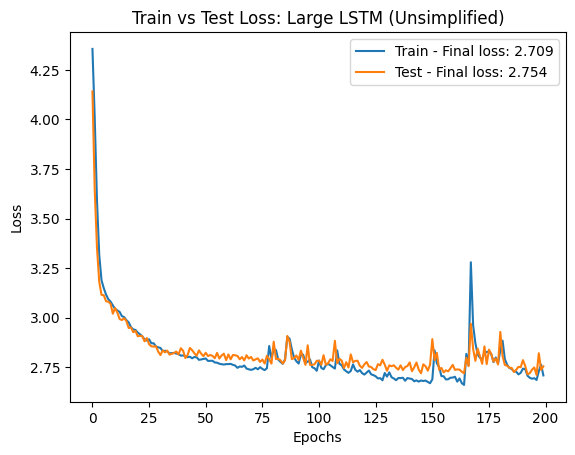

In [ ]:
plot_loss("large_epoch_loss_train.txt", "large_epoch_loss_test.txt", epochs, "Large LSTM (Unsimplified)")

### Large LSTM - Simplified Chords


#### Model Class Definitions (same as previous)


In [ ]:
class AudioLargeLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout):
        super(AudioLargeLSTM, self).__init__()
        # LSTM with dropout
        self.lstm = nn.LSTM(input_size=input_dim,
                            hidden_size=hidden_dim,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout)
        # Layer Normalization
        self.layernorm = nn.LayerNorm(hidden_dim)
        # Fully Connected Layer
        self.fc = nn.Linear(in_features=hidden_dim, out_features=output_dim)

    def forward(self, x):
        packed_output, _ = self.lstm(x)  # run LSTM layer
        output, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        output_normalized = self.layernorm(output)
        return self.fc(output_normalized)

#### Training


In [ ]:
# Preprocessing - Tokenizing for 36 chord classes
root_chords_no_nan = set(filter(lambda item: isinstance(item, str), root_chords))
idx_to_chord = sorted(list(root_chords_no_nan))  # mapping of index-to-chords
base_chords = extract_unique_base_chords_m_dim(idx_to_chord)
idx_to_chord = sorted(list(base_chords))  # mapping of index-to-chords
idx_to_chord = ['<PAD>'] + idx_to_chord
chord_to_idx = {chord: i for i, chord in enumerate(idx_to_chord)}
print("idx_to_chord:\t", idx_to_chord)
print("chord_to_idx:\t", chord_to_idx)
print('Num Chords:', len(idx_to_chord))
print('Num Base Chords:', len(set(base_chords)))

set_simplified_chords()

NameError: name 'root_chords' is not defined

In [ ]:
input_files = "./datashare/" + train_df["location"]
test_input_files = "./datashare/" + test_df['location']

train_chroma_ds = ChromaDataset(filepaths=input_files, chord_labels=train_df['chords'], chord_times=train_df['chords_time'], npy_dir='chroma_features', device=device)
test_chroma_ds = ChromaDataset(filepaths=test_input_files, chord_labels=test_df['chords'], chord_times=test_df['chords_time'], npy_dir='chroma_features_test', device=device)
train_dataloader = DataLoader(train_chroma_ds, batch_size=1024, shuffle=True, collate_fn=collate_fn)
test_dataloader = DataLoader(test_chroma_ds, batch_size=1024, shuffle=False, collate_fn=collate_fn)

# Examine dataloader
packed_sequences, packed_labels, lengths, _, _ = next(iter(train_dataloader))
packed_sequences, packed_labels, lengths = packed_sequences.to(device), packed_labels.to(device), lengths.to(device)
print("Packed sequences:", packed_sequences.data.shape)
print("Packed labels:", packed_labels.data.shape)
print("Sequence lengths:", lengths[:10])

Packed sequences: torch.Size([314151, 12])
Packed labels: torch.Size([1024, 313])
Sequence lengths: tensor([313, 313, 313, 313, 313, 313, 313, 313, 313, 313], device='cuda:0')


In [ ]:
input_dim = 12  # Chroma feature dimensions (12, 313) --> 12 pitches
hidden_dim = 256  # hyperparameter
output_dim = 35  # Number of Chords: 34 + <PAD> 
num_layers = 4
dropout = 0.2

lstm_simplified_model = AudioLargeLSTM(input_dim, hidden_dim, output_dim, num_layers, dropout).to(device)
print(lstm_simplified_model)

AudioLargeLSTM(
  (lstm): LSTM(12, 256, num_layers=4, batch_first=True, dropout=0.2)
  (layernorm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=256, out_features=36, bias=True)
)


In [ ]:
# HYPERPARAMETERS
lr = 0.001
regularization = 0.003
loss_fn = nn.CrossEntropyLoss(ignore_index=chord_to_idx['<PAD>']).to(device)
start_epoch = 0
epochs = 10

# CHECKPOINTING
checkpoint_path = 'checkpoints/lstm_simplified_150.pt'
checkpoint = torch.load(checkpoint_path, map_location=device)

# Load checkpoint model state
lstm_simplified_model.load_state_dict(checkpoint['model_state_dict'])

# Load checkpoint optimizer state
opt = torch.optim.Adam(lstm_simplified_model.parameters(), lr=lr, weight_decay=regularization)
opt.load_state_dict(checkpoint['optimizer_state_dict'])

# Load Learning Rate Scheduler
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5, verbose=True)
lr_scheduler.load_state_dict(checkpoint['lr_scheduler_state_dict'])

# Load GradScaler
scaler = torch.amp.GradScaler(device, enabled=True)
# the code below is only used for resuming training, so comment out if its your first time running the model
scaler.load_state_dict(checkpoint['scaler_state_dict'])  

# Other checkpoint vals
start_epoch = checkpoint['epoch'] + 1
previous_loss = checkpoint['loss']
print("Previous Loss:", previous_loss)

Previous Loss: 2.187488390849187


In [ ]:
train_model(lstm_simplified_model, opt, scaler, loss_fn,
            train_dataloader, test_dataloader,
            output_dim, start_epoch, epochs,
            "checkpoints/lstm_simplified", 10, "simplified_epoch_loss",
            lr_scheduler=lr_scheduler)

Epoch 1, batch 1, Batch Loss: 3.7965448
Epoch 1, batch 11, Batch Loss: 3.3101897
Epoch 1, batch 21, Batch Loss: 3.2623715
Epoch 1, batch 31, Batch Loss: 3.1915042
Epoch 1, batch 41, Batch Loss: 3.1149237
Epoch 1, batch 51, Batch Loss: 2.9312077
---------- Epoch 1, Train Loss: 3.2049713, Test Loss: 2.9260201 ----------
Epoch 2, batch 1, Batch Loss: 3.0248702
Epoch 2, batch 11, Batch Loss: 2.8975298
Epoch 2, batch 21, Batch Loss: 2.8248091
Epoch 2, batch 31, Batch Loss: 2.7427707
Epoch 2, batch 41, Batch Loss: 2.7719524
Epoch 2, batch 51, Batch Loss: 2.6790428
---------- Epoch 2, Train Loss: 2.8010815, Test Loss: 2.5623600 ----------
Epoch 3, batch 1, Batch Loss: 2.6767156
Epoch 3, batch 11, Batch Loss: 2.6627564
Epoch 3, batch 21, Batch Loss: 2.6757822
Epoch 3, batch 31, Batch Loss: 2.6340475
Epoch 3, batch 41, Batch Loss: 2.5888500
Epoch 3, batch 51, Batch Loss: 2.5681736
---------- Epoch 3, Train Loss: 2.6482551, Test Loss: 2.5788262 ----------
Epoch 4, batch 1, Batch Loss: 2.6357229


#### Testing


In [ ]:
# NOTE: evaluate with enharmonic filtering OFF on batch 0, sub-batch 600 to see enharmonic chords present (D# and Eb)
# but turn ON enharmonic filtering, and they disappear. This must be done manually in sample_eval()

# Threshold = 0, enharmonic filtering OFF 
audiofile = sample_eval(lstm_simplified_model, test_dataloader, 0, 600, output_dim, loss_fn, 0, audio=False)

[(tensor(0.1943), 'Bb'), (tensor(0.1955), 'Bb'), (tensor(0.1962), 'Bb'), (tensor(0.1965), 'Bb'), (tensor(0.1958), 'Bb'), (tensor(0.1934), 'Bb'), (tensor(0.1910), 'Bb'), (tensor(0.1894), 'Bb'), (tensor(0.1886), 'Bb'), (tensor(0.1889), 'Bb'), (tensor(0.1902), 'Bb'), (tensor(0.1916), 'Bb'), (tensor(0.1928), 'Bb'), (tensor(0.1941), 'Bb'), (tensor(0.1951), 'Bb'), (tensor(0.1966), 'Bb'), (tensor(0.1988), 'Bb'), (tensor(0.2023), 'Bb'), (tensor(0.2074), 'Bb'), (tensor(0.2130), 'Bb'), (tensor(0.2189), 'Bb'), (tensor(0.2251), 'Bb'), (tensor(0.2313), 'Bb'), (tensor(0.2362), 'Bb'), (tensor(0.2400), 'Bb'), (tensor(0.2438), 'Bb'), (tensor(0.2461), 'Bb'), (tensor(0.2478), 'Bb'), (tensor(0.2489), 'Bb'), (tensor(0.2496), 'Bb'), (tensor(0.2496), 'Bb'), (tensor(0.2497), 'Bb'), (tensor(0.2499), 'Bb'), (tensor(0.2510), 'Bb'), (tensor(0.2525), 'Bb'), (tensor(0.2551), 'Bb'), (tensor(0.2575), 'Bb'), (tensor(0.2596), 'Bb'), (tensor(0.2611), 'Bb'), (tensor(0.2618), 'Bb'), (tensor(0.2622), 'Bb'), (tensor(0.2616)

In [ ]:
# Threshold = 0, enharmonic filtering ON
audiofile = sample_eval(lstm_simplified_model, test_dataloader, 0, 600, output_dim, loss_fn, 0, audio=False)

[(tensor(0.1943), 'Bb'), (tensor(0.1955), 'Bb'), (tensor(0.1962), 'Bb'), (tensor(0.1965), 'Bb'), (tensor(0.1958), 'Bb'), (tensor(0.1934), 'Bb'), (tensor(0.1910), 'Bb'), (tensor(0.1894), 'Bb'), (tensor(0.1886), 'Bb'), (tensor(0.1889), 'Bb'), (tensor(0.1902), 'Bb'), (tensor(0.1916), 'Bb'), (tensor(0.1928), 'Bb'), (tensor(0.1941), 'Bb'), (tensor(0.1951), 'Bb'), (tensor(0.1966), 'Bb'), (tensor(0.1988), 'Bb'), (tensor(0.2023), 'Bb'), (tensor(0.2074), 'Bb'), (tensor(0.2130), 'Bb'), (tensor(0.2189), 'Bb'), (tensor(0.2251), 'Bb'), (tensor(0.2313), 'Bb'), (tensor(0.2362), 'Bb'), (tensor(0.2400), 'Bb'), (tensor(0.2438), 'Bb'), (tensor(0.2461), 'Bb'), (tensor(0.2478), 'Bb'), (tensor(0.2489), 'Bb'), (tensor(0.2496), 'Bb'), (tensor(0.2496), 'Bb'), (tensor(0.2497), 'Bb'), (tensor(0.2499), 'Bb'), (tensor(0.2510), 'Bb'), (tensor(0.2525), 'Bb'), (tensor(0.2551), 'Bb'), (tensor(0.2575), 'Bb'), (tensor(0.2596), 'Bb'), (tensor(0.2611), 'Bb'), (tensor(0.2618), 'Bb'), (tensor(0.2622), 'Bb'), (tensor(0.2616)

In [ ]:
# Threshold = 0.2
audiofile = sample_eval(lstm_simplified_model, test_dataloader, 0, 600, output_dim, loss_fn, 0.2, audio=False)

[(tensor(0.1943), 'Bb'), (tensor(0.1955), 'Bb'), (tensor(0.1962), 'Bb'), (tensor(0.1965), 'Bb'), (tensor(0.1958), 'Bb'), (tensor(0.1934), 'Bb'), (tensor(0.1910), 'Bb'), (tensor(0.1894), 'Bb'), (tensor(0.1886), 'Bb'), (tensor(0.1889), 'Bb'), (tensor(0.1902), 'Bb'), (tensor(0.1916), 'Bb'), (tensor(0.1928), 'Bb'), (tensor(0.1941), 'Bb'), (tensor(0.1951), 'Bb'), (tensor(0.1966), 'Bb'), (tensor(0.1988), 'Bb'), (tensor(0.2023), 'Bb'), (tensor(0.2074), 'Bb'), (tensor(0.2130), 'Bb'), (tensor(0.2189), 'Bb'), (tensor(0.2251), 'Bb'), (tensor(0.2313), 'Bb'), (tensor(0.2362), 'Bb'), (tensor(0.2400), 'Bb'), (tensor(0.2438), 'Bb'), (tensor(0.2461), 'Bb'), (tensor(0.2478), 'Bb'), (tensor(0.2489), 'Bb'), (tensor(0.2496), 'Bb'), (tensor(0.2496), 'Bb'), (tensor(0.2497), 'Bb'), (tensor(0.2499), 'Bb'), (tensor(0.2510), 'Bb'), (tensor(0.2525), 'Bb'), (tensor(0.2551), 'Bb'), (tensor(0.2575), 'Bb'), (tensor(0.2596), 'Bb'), (tensor(0.2611), 'Bb'), (tensor(0.2618), 'Bb'), (tensor(0.2622), 'Bb'), (tensor(0.2616)

In [ ]:
# Threshold = 0.4
audiofile = sample_eval(lstm_simplified_model, test_dataloader, 0, 600, output_dim, loss_fn, 0.4, audio=True)

[(tensor(0.1943), 'Bb'), (tensor(0.1955), 'Bb'), (tensor(0.1962), 'Bb'), (tensor(0.1965), 'Bb'), (tensor(0.1958), 'Bb'), (tensor(0.1934), 'Bb'), (tensor(0.1910), 'Bb'), (tensor(0.1894), 'Bb'), (tensor(0.1886), 'Bb'), (tensor(0.1889), 'Bb'), (tensor(0.1902), 'Bb'), (tensor(0.1916), 'Bb'), (tensor(0.1928), 'Bb'), (tensor(0.1941), 'Bb'), (tensor(0.1951), 'Bb'), (tensor(0.1966), 'Bb'), (tensor(0.1988), 'Bb'), (tensor(0.2023), 'Bb'), (tensor(0.2074), 'Bb'), (tensor(0.2130), 'Bb'), (tensor(0.2189), 'Bb'), (tensor(0.2251), 'Bb'), (tensor(0.2313), 'Bb'), (tensor(0.2362), 'Bb'), (tensor(0.2400), 'Bb'), (tensor(0.2438), 'Bb'), (tensor(0.2461), 'Bb'), (tensor(0.2478), 'Bb'), (tensor(0.2489), 'Bb'), (tensor(0.2496), 'Bb'), (tensor(0.2496), 'Bb'), (tensor(0.2497), 'Bb'), (tensor(0.2499), 'Bb'), (tensor(0.2510), 'Bb'), (tensor(0.2525), 'Bb'), (tensor(0.2551), 'Bb'), (tensor(0.2575), 'Bb'), (tensor(0.2596), 'Bb'), (tensor(0.2611), 'Bb'), (tensor(0.2618), 'Bb'), (tensor(0.2622), 'Bb'), (tensor(0.2616)

In [ ]:
predict_chords(audiofile, lstm_simplified_model, 0, True)

torch.Size([1, 313, 12])
Model output shape: torch.Size([1, 313, 36])
Model idx shape: torch.Size([313])
Max chord per frame: ['<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', '<NULL>', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'D#', 'Gm', 'Gm', 'Gm', 'Gm', 'Gm', 'Gm', 'Gm', 'Eb', 'Eb', 'Eb', 'Eb', 'Eb', 'Eb', 'Eb', 'Eb', 'Eb', 'Eb', 'Eb', 'Eb', 'Eb', 'Eb', 'Eb', 'Eb', 'Eb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb', 'Bb',

'./datashare/data/-4SYC2YgzL8.wav'

In [ ]:
play_audio(audiofile)

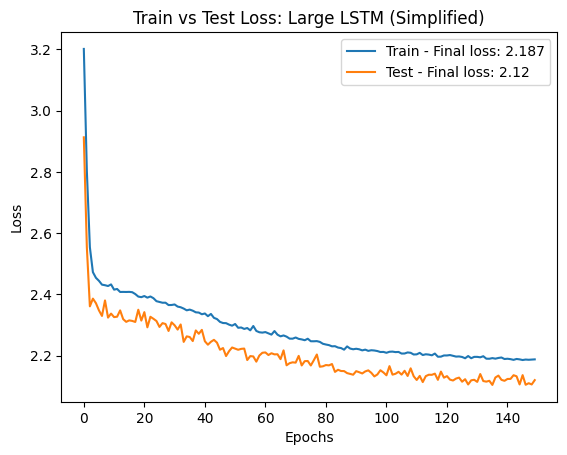

In [ ]:
plot_loss("simplified_epoch_loss_train.txt", "simplified_epoch_loss_test.txt", epochs, "Large LSTM (Simplified)")

### Giant LSTM - Simplified Chords

#### Model Class Definitions (same as previous)

#### Training

In [ ]:
# Preprocessing - Tokenizing for 36 chord classes
root_chords_no_nan = set(filter(lambda item: isinstance(item, str), root_chords))
idx_to_chord = sorted(list(root_chords_no_nan))  # mapping of index-to-chords
base_chords = extract_unique_base_chords_m_dim(idx_to_chord)
idx_to_chord = sorted(list(base_chords))  # mapping of index-to-chords
idx_to_chord = ['<PAD>'] + idx_to_chord
chord_to_idx = {chord: i for i, chord in enumerate(idx_to_chord)}
print("idx_to_chord:\t", idx_to_chord)
print("chord_to_idx:\t", chord_to_idx)
print('Num Chords:', len(idx_to_chord))
print('Num Base Chords:', len(set(base_chords)))

set_simplified_chords()

idx_to_chord:	 ['<PAD>', '<NULL>', 'A', 'A#', 'A#m', 'Ab', 'Abm', 'Am', 'B', 'Bb', 'Bbm', 'Bm', 'C', 'C#', 'C#m', 'Cm', 'D', 'D#', 'D#m', 'Db', 'Dbm', 'Dm', 'E', 'Eb', 'Ebm', 'Em', 'F', 'F#', 'F#m', 'Fm', 'G', 'G#', 'G#m', 'Gb', 'Gbm', 'Gm']
chord_to_idx:	 {'<PAD>': 0, '<NULL>': 1, 'A': 2, 'A#': 3, 'A#m': 4, 'Ab': 5, 'Abm': 6, 'Am': 7, 'B': 8, 'Bb': 9, 'Bbm': 10, 'Bm': 11, 'C': 12, 'C#': 13, 'C#m': 14, 'Cm': 15, 'D': 16, 'D#': 17, 'D#m': 18, 'Db': 19, 'Dbm': 20, 'Dm': 21, 'E': 22, 'Eb': 23, 'Ebm': 24, 'Em': 25, 'F': 26, 'F#': 27, 'F#m': 28, 'Fm': 29, 'G': 30, 'G#': 31, 'G#m': 32, 'Gb': 33, 'Gbm': 34, 'Gm': 35}
Num Chords: 36
Num Base Chords: 34


In [ ]:
input_files = "./datashare/" + train_df["location"]
test_input_files = "./datashare/" + test_df['location']

train_chroma_ds = ChromaDataset(filepaths=input_files, chord_labels=train_df['chords'], chord_times=train_df['chords_time'], npy_dir='chroma_features', device=device)
test_chroma_ds = ChromaDataset(filepaths=test_input_files, chord_labels=test_df['chords'], chord_times=test_df['chords_time'], npy_dir='chroma_features_test', device=device)
train_dataloader = DataLoader(train_chroma_ds, batch_size=1024, shuffle=True, collate_fn=collate_fn)
test_dataloader = DataLoader(test_chroma_ds, batch_size=1024, shuffle=False, collate_fn=collate_fn)

# Examine dataloader
packed_sequences, packed_labels, lengths, _, _ = next(iter(train_dataloader))
packed_sequences, packed_labels, lengths = packed_sequences.to(device), packed_labels.to(device), lengths.to(device)
print("Packed sequences:", packed_sequences.data.shape)
print("Packed labels:", packed_labels.data.shape)
print("Sequence lengths:", lengths[:10])

Packed sequences: torch.Size([314468, 12])
Packed labels: torch.Size([1024, 313])
Sequence lengths: tensor([313, 313, 313, 313, 313, 313, 313, 313, 313, 313], device='cuda:0')


In [ ]:
input_dim = 12  # Chroma feature dimensions (12, 313) --> 12 pitches
hidden_dim = 300  # hyperparameter
output_dim = 35  # Number of Chords: 34 + <PAD> 
num_layers = 5
dropout = 0.2

giant_lstm_simplified_model = AudioLargeLSTM(input_dim, hidden_dim, output_dim, num_layers, dropout).to(device)
print(giant_lstm_simplified_model)

AudioLargeLSTM(
  (lstm): LSTM(12, 300, num_layers=5, batch_first=True, dropout=0.2)
  (layernorm): LayerNorm((300,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=300, out_features=36, bias=True)
)


In [ ]:
# HYPERPARAMETERS
lr = 0.001
regularization = 0.003
loss_fn = nn.CrossEntropyLoss(ignore_index=chord_to_idx['<PAD>']).to(device)
start_epoch = 0
epochs = 100

# CHECKPOINTING
checkpoint_path = 'checkpoints/giant_lstm_simplified_1.pt'
checkpoint = torch.load(checkpoint_path, map_location=device)

# Load checkpoint model state
giant_lstm_simplified_model.load_state_dict(checkpoint['model_state_dict'])

# Load checkpoint optimizer state
opt = torch.optim.Adam(giant_lstm_simplified_model.parameters(), lr=lr, weight_decay=regularization)
opt.load_state_dict(checkpoint['optimizer_state_dict'])

# Load Learning Rate Scheduler
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5, verbose=True)
lr_scheduler.load_state_dict(checkpoint['lr_scheduler_state_dict'])

# Load GradScaler
scaler = torch.amp.GradScaler(device, enabled=True)
# the code below is only used for resuming training, so comment out if its your first time running the model
scaler.load_state_dict(checkpoint['scaler_state_dict'])  

# Other checkpoint vals
start_epoch = checkpoint['epoch'] + 1
previous_loss = checkpoint['loss']
print("Previous Loss:", previous_loss)

Previous Loss: 3.2837860263310947


In [ ]:
train_model(giant_lstm_simplified_model, opt, scaler, loss_fn,
            train_dataloader, test_dataloader,
            output_dim, start_epoch, epochs,
            "checkpoints/giant_lstm_simplified", 10, "giant_simplified_epoch_loss",
            lr_scheduler=lr_scheduler)

Epoch 2, batch 1, Batch Loss: 3.2164598
Epoch 2, batch 11, Batch Loss: 3.1927650
Epoch 2, batch 21, Batch Loss: 3.2532930
Epoch 2, batch 31, Batch Loss: 3.2184186
Epoch 2, batch 41, Batch Loss: 3.1959915
Epoch 2, batch 51, Batch Loss: 3.1860430
---------- Epoch 2, Train Loss: 3.2235646, Test Loss: 3.0899124 ----------
Epoch 3, batch 1, Batch Loss: 3.1909404
Epoch 3, batch 11, Batch Loss: 3.2256248
Epoch 3, batch 21, Batch Loss: 3.2054667
Epoch 3, batch 31, Batch Loss: 3.1934352
Epoch 3, batch 41, Batch Loss: 3.2086842
Epoch 3, batch 51, Batch Loss: 3.2052171
---------- Epoch 3, Train Loss: 3.1938936, Test Loss: 3.0925603 ----------
Epoch 4, batch 1, Batch Loss: 3.1868534
Epoch 4, batch 11, Batch Loss: 3.1758041
Epoch 4, batch 21, Batch Loss: 3.1925232
Epoch 4, batch 31, Batch Loss: 3.1955013
Epoch 4, batch 41, Batch Loss: 3.1936445
Epoch 4, batch 51, Batch Loss: 3.1840901
---------- Epoch 4, Train Loss: 3.1928185, Test Loss: 3.0999045 ----------
Epoch 5, batch 1, Batch Loss: 3.1879010


KeyboardInterrupt: 

#### Testing

In [ ]:
# Threshold = 0
audiofile = sample_eval(lstm_simplified_model, test_dataloader, 0, 600, output_dim, loss_fn, 0, audio=False)

In [ ]:
play_audio(audiofile)

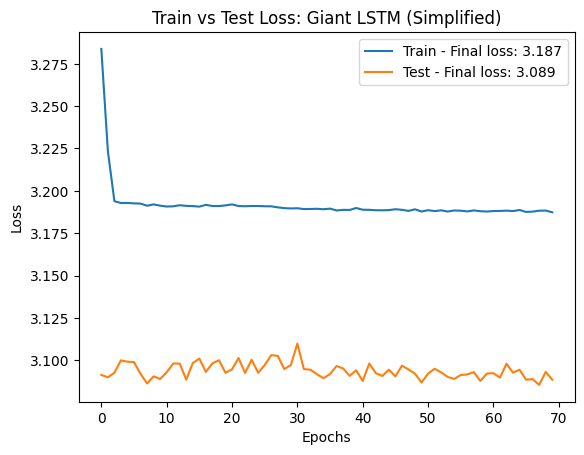

In [ ]:
plot_loss("giant_simplified_epoch_loss_train.txt", "giant_simplified_epoch_loss_test.txt", 70, "Giant LSTM (Simplified)")

### Harmonic LSTM - Simplified

#### Model Class Definitions

In [23]:
class AudioLargeLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout):
        super(AudioLargeLSTM, self).__init__()
        # LSTM with dropout
        self.lstm = nn.LSTM(input_size=input_dim,
                            hidden_size=hidden_dim,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout)
        # Layer Normalization
        self.layernorm = nn.LayerNorm(hidden_dim)
        # Fully Connected Layer
        self.fc = nn.Linear(in_features=hidden_dim, out_features=output_dim)

    def forward(self, x):
        packed_output, _ = self.lstm(x)  # run LSTM layer
        output, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        output_normalized = self.layernorm(output)
        return self.fc(output_normalized)

#### Training

In [24]:
# Preprocessing - Tokenizing for 36 chord classes
root_chords_no_nan = set(filter(lambda item: isinstance(item, str), root_chords))
idx_to_chord = sorted(list(root_chords_no_nan))  # mapping of index-to-chords
base_chords = extract_unique_base_chords_m_dim(idx_to_chord)
idx_to_chord = sorted(list(base_chords))  # mapping of index-to-chords
idx_to_chord = ['<PAD>'] + idx_to_chord
chord_to_idx = {chord: i for i, chord in enumerate(idx_to_chord)}
print("idx_to_chord:\t", idx_to_chord)
print("chord_to_idx:\t", chord_to_idx)
print('Num Chords:', len(idx_to_chord))
print('Num Base Chords:', len(set(base_chords)))

# Tonnetz Embedding for harmonic loss
embedding_list = []
for chord in idx_to_chord:
    tonnetz_vector = compute_tonnetz_embedding(chord)  # shape (6,)
    embedding_list.append(tonnetz_vector)
chord_embeddings = torch.tensor(np.array(embedding_list), dtype=torch.float32, device=device) # (num_chords, 6)
print("Chord Embeddings Shape:", chord_embeddings.shape)
print("Chord Embedding for C:", chord_embeddings[1])

set_simplified_chords()

idx_to_chord:	 ['<PAD>', 'A', 'A#', 'A#m', 'Ab', 'Abm', 'Am', 'B', 'Bb', 'Bbm', 'Bm', 'C', 'C#', 'C#m', 'Cm', 'D', 'D#', 'D#m', 'Db', 'Dbm', 'Dm', 'E', 'Eb', 'Ebm', 'Em', 'F', 'F#', 'F#m', 'Fm', 'G', 'G#', 'G#m', 'Gb', 'Gbm', 'Gm']
chord_to_idx:	 {'<PAD>': 0, 'A': 1, 'A#': 2, 'A#m': 3, 'Ab': 4, 'Abm': 5, 'Am': 6, 'B': 7, 'Bb': 8, 'Bbm': 9, 'Bm': 10, 'C': 11, 'C#': 12, 'C#m': 13, 'Cm': 14, 'D': 15, 'D#': 16, 'D#m': 17, 'Db': 18, 'Dbm': 19, 'Dm': 20, 'E': 21, 'Eb': 22, 'Ebm': 23, 'Em': 24, 'F': 25, 'F#': 26, 'F#m': 27, 'Fm': 28, 'G': 29, 'G#': 30, 'G#m': 31, 'Gb': 32, 'Gbm': 33, 'Gm': 34}
Num Chords: 35
Num Base Chords: 34
Chord Embeddings Shape: torch.Size([35, 6])
Chord Embedding for C: tensor([ 4.5534e-01, -4.5534e-01, -6.6667e-01,  3.3333e-01,  2.8868e-01,
         1.6653e-16], device='cuda:0')


In [25]:
input_files = "./datashare/" + train_df["location"]
test_input_files = "./datashare/" + test_df['location']

train_chroma_ds = ChromaDataset(filepaths=input_files, chord_labels=train_df['chords'], chord_times=train_df['chords_time'], npy_dir='chroma_features', device=device)
test_chroma_ds = ChromaDataset(filepaths=test_input_files, chord_labels=test_df['chords'], chord_times=test_df['chords_time'], npy_dir='chroma_features_test', device=device)
train_dataloader = DataLoader(train_chroma_ds, batch_size=1024, shuffle=True, collate_fn=collate_fn)
test_dataloader = DataLoader(test_chroma_ds, batch_size=1024, shuffle=False, collate_fn=collate_fn)

# Examine dataloader
packed_sequences, packed_labels, lengths, _, _ = next(iter(train_dataloader))
packed_sequences, packed_labels, lengths = packed_sequences.to(device), packed_labels.to(device), lengths.to(device)
print("Packed sequences:", packed_sequences.data.shape)
print("Packed labels:", packed_labels.data.shape)
print("Sequence lengths:", lengths[:10])

Packed sequences: torch.Size([314083, 12])
Packed labels: torch.Size([1024, 313])
Sequence lengths: tensor([313, 313, 313, 313, 313, 313, 313, 313, 313, 313], device='cuda:0')


In [26]:
input_dim = 12  # Chroma feature dimensions (12, 313) --> 12 pitches
hidden_dim = 256  # hyperparameter
output_dim = 35  # Number of Chords: 34 + <PAD> 
num_layers = 4
dropout = 0.2

harmonic_lstm_model = AudioLargeLSTM(input_dim, hidden_dim, output_dim, num_layers, dropout).to(device)
print(harmonic_lstm_model)

AudioLargeLSTM(
  (lstm): LSTM(12, 256, num_layers=4, batch_first=True, dropout=0.2)
  (layernorm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=256, out_features=35, bias=True)
)


In [ ]:
# HYPERPARAMETERS
lr = 0.004
regularization = 0.003
loss_fn = HarmonicCrossEntropyLoss(chord_embeddings, alpha=0.6, ignore_index=chord_to_idx['<PAD>'], device=device)
start_epoch = 0
epochs = 2

# CHECKPOINTING
# checkpoint_path = 'checkpoints/harmonic_lstm_1.pt'
# checkpoint = torch.load(checkpoint_path, map_location=device)

# Load checkpoint model state
# harmonic_lstm_model.load_state_dict(checkpoint['model_state_dict'])

# Load checkpoint optimizer state
opt = torch.optim.Adam(harmonic_lstm_model.parameters(), lr=lr, weight_decay=regularization)
# opt.load_state_dict(checkpoint['optimizer_state_dict'])

# NEW: Load GradScaler
scaler = torch.amp.GradScaler(device, enabled=True)
# scaler.load_state_dict(checkpoint['scaler_state_dict'])  

# Other checkpoint vals
# start_epoch = checkpoint['epoch'] + 1
# previous_loss = checkpoint['loss']
# print("Previous Loss:", previous_loss)

In [33]:
train_model(harmonic_lstm_model, opt, scaler, loss_fn, train_dataloader, test_dataloader, output_dim, start_epoch, epochs, "checkpoints/harmonic_lstm", 10, "harmonic_lstm_epoch_loss")

Epoch 1, batch 1, Batch Loss: 1.7383751
Epoch 1, batch 11, Batch Loss: 1.7472533
Epoch 1, batch 21, Batch Loss: 1.7597313
Epoch 1, batch 31, Batch Loss: 1.7481380
Epoch 1, batch 41, Batch Loss: 1.7481002
Epoch 1, batch 51, Batch Loss: 1.7458724
---------- Epoch 1, Train Loss: 1.7484472, Test Loss: 1.7058241 ----------
Epoch 2, batch 1, Batch Loss: 1.7389951
Epoch 2, batch 11, Batch Loss: 1.7536263
Epoch 2, batch 21, Batch Loss: 1.7462666
Epoch 2, batch 31, Batch Loss: 1.7567272
Epoch 2, batch 41, Batch Loss: 1.7360762
Epoch 2, batch 51, Batch Loss: 1.7412415
---------- Epoch 2, Train Loss: 1.7476376, Test Loss: 1.7043469 ----------


#### Testing

In [29]:
# Threshold = 0
audiofile = sample_eval(harmonic_lstm_model, test_dataloader, 0, 600, output_dim, loss_fn, 0, audio=False)

[(tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.0687), 'G'), (tensor(0.